In [ ]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
from logitlense import PosLogitLensAnalyzer
import pandas as pd
from transformers import AutoModelForMaskedLM, AutoTokenizer
import sys
sys.path.insert(0, "/mlama")  
from dataset.reader import MLama
import torch.nn.functional as F
from visualizer import Visualizer

import warnings
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")
warnings.filterwarnings(
    "ignore",
    message=".*figure layout has changed to tight.*",
    category=UserWarning,
)

In [2]:
viz = Visualizer()

subjects = ["COL", "GFW", "JUS", "KOP", "TYE", "ZEK"]
model_names_zh = ["mBERT_zh_Base", "mBERT_zh_Whole", "mBERT_zh_Semantic", "mBERT_zh_Language"]
model_names_en = ["mBERT_en_Base", "mBERT_en_Whole", "mBERT_en_Semantic", "mBERT_en_Language"]

# NOUN

In [3]:
family = "mBERT"
target = "POS-Noun"


full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT-en

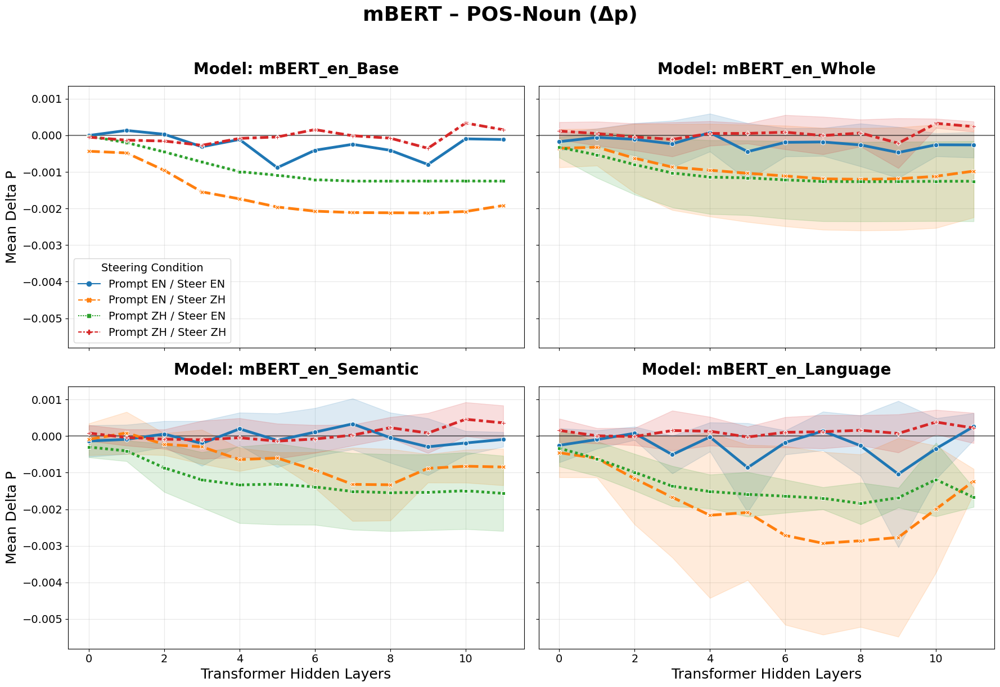

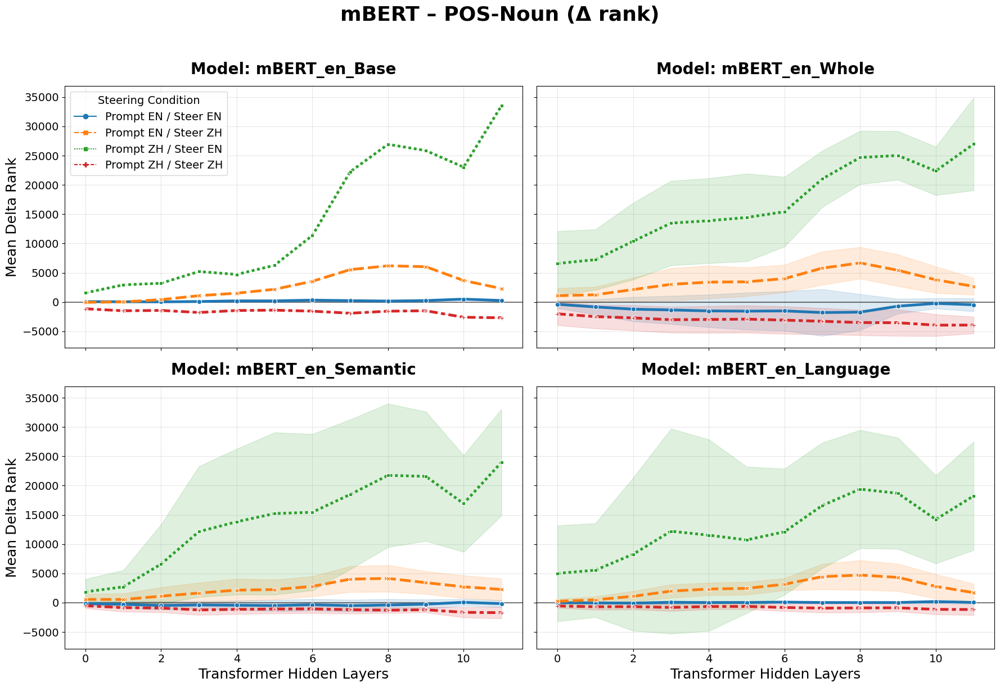

In [4]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-Noun (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      1      0.000134
    mBERT_en_Base          en         zh      0     -0.000435
    mBERT_en_Base          zh         en      0     -0.000024
    mBERT_en_Base          zh         zh     10      0.000336
mBERT_en_Language          en         en     11      0.000260
mBERT_en_Language          en         zh      0     -0.000456
mBERT_en_Language          zh         en      0     -0.000333
mBERT_en_Language          zh         zh     10      0.000383
mBERT_en_Semantic          en         en      7      0.000332
mBERT_en_Semantic          en         zh      1      0.000084
mBERT_en_Semantic          zh         en      0     -0.000302
mBERT_en_Semantic          zh         zh     10      0.000458
   mBERT_en_Whole          en         en      4      0.000075
   mBERT_en_Whole          en         zh      1     -0.000324
   

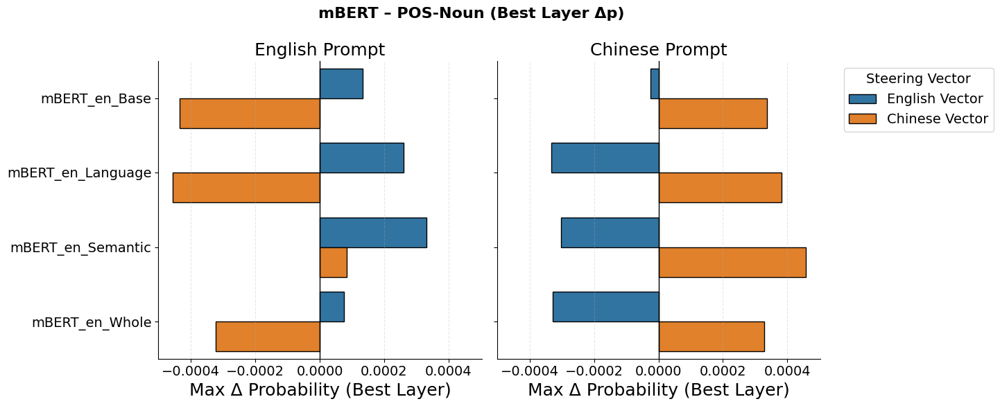

In [5]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-Noun (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en      2        27.760000
    mBERT_en_Base          en         zh      0       -53.480000
    mBERT_en_Base          zh         en      0      1566.860000
    mBERT_en_Base          zh         zh     11     -2691.060000
mBERT_en_Language          en         en      2       -66.650000
mBERT_en_Language          en         zh      0       245.403333
mBERT_en_Language          zh         en      0      5005.063333
mBERT_en_Language          zh         zh     11     -1163.396667
mBERT_en_Semantic          en         en      7      -495.783333
mBERT_en_Semantic          en         zh      1       552.156667
mBERT_en_Semantic          zh         en      0      1854.290000
mBERT_en_Semantic          zh         zh     11     -1704.993333
   mBERT_en_Whole          en         en      7     -1800.460000
   mBERT_en_Whole      

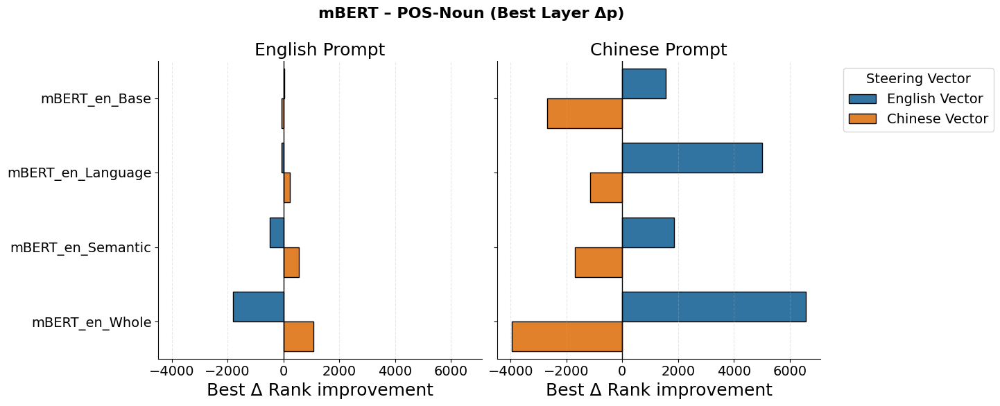

In [6]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

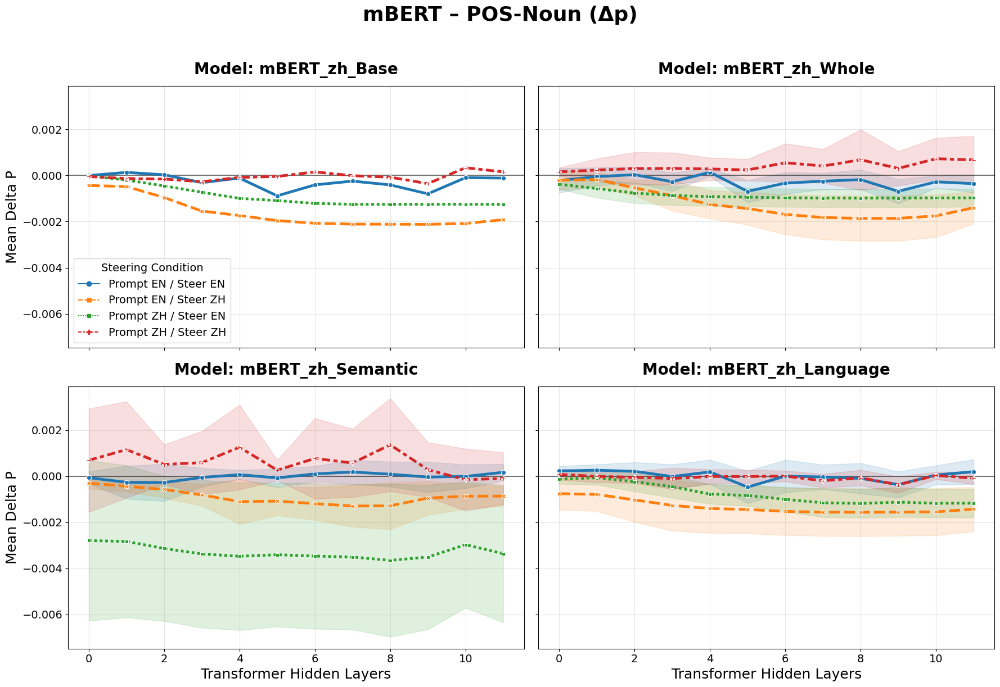

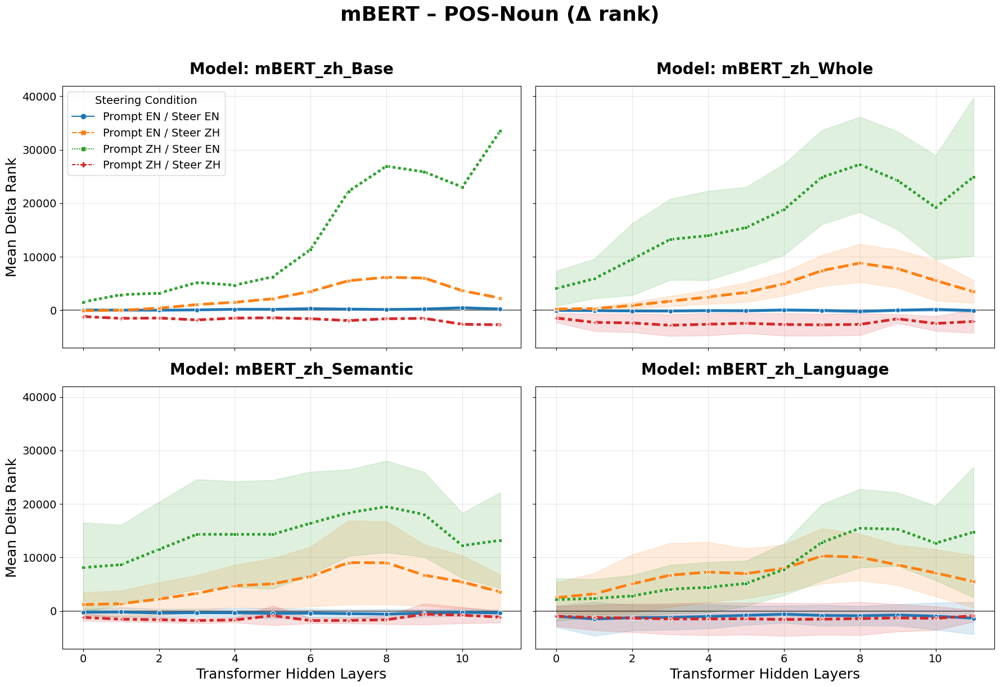

In [7]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-Noun (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      1      0.000134
    mBERT_zh_Base          en         zh      0     -0.000435
    mBERT_zh_Base          zh         en      0     -0.000024
    mBERT_zh_Base          zh         zh     10      0.000336
mBERT_zh_Language          en         en      1      0.000257
mBERT_zh_Language          en         zh      0     -0.000757
mBERT_zh_Language          zh         en      1     -0.000071
mBERT_zh_Language          zh         zh      0      0.000078
mBERT_zh_Semantic          en         en      7      0.000180
mBERT_zh_Semantic          en         zh      0     -0.000302
mBERT_zh_Semantic          zh         en      0     -0.002794
mBERT_zh_Semantic          zh         zh      8      0.001357
   mBERT_zh_Whole          en         en      4      0.000139
   mBERT_zh_Whole          en         zh      1     -0.000177
   

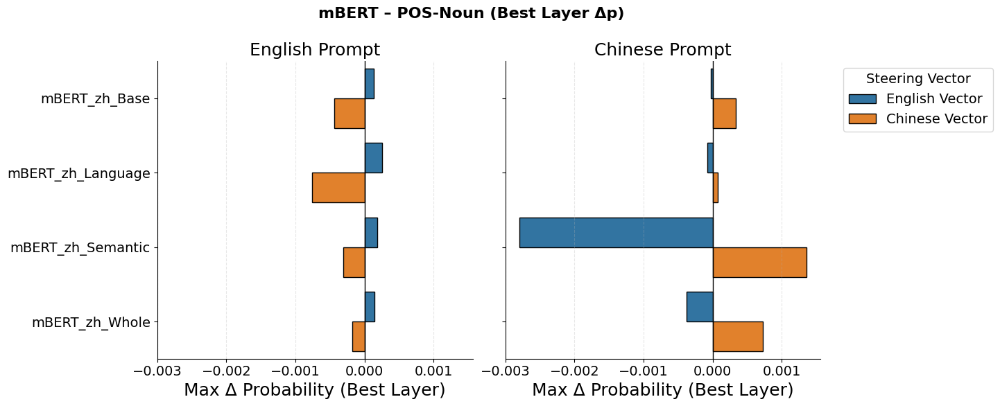

In [8]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-Noun (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en      2        27.760000
    mBERT_zh_Base          en         zh      0       -53.480000
    mBERT_zh_Base          zh         en      0      1566.860000
    mBERT_zh_Base          zh         zh     11     -2691.060000
mBERT_zh_Language          en         en      1     -1482.280000
mBERT_zh_Language          en         zh      0      2503.686667
mBERT_zh_Language          zh         en      0      2139.010000
mBERT_zh_Language          zh         zh      6     -1579.406667
mBERT_zh_Semantic          en         en      8      -561.843333
mBERT_zh_Semantic          en         zh      0      1199.006667
mBERT_zh_Semantic          zh         en      0      8128.686667
mBERT_zh_Semantic          zh         zh      6     -1782.843333
   mBERT_zh_Whole          en         en      8      -187.096667
   mBERT_zh_Whole      

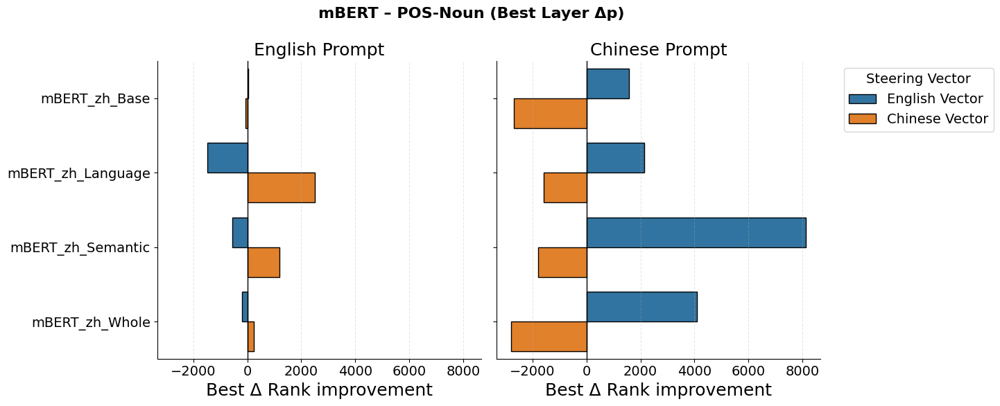

In [9]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# VERB

In [10]:
family = "mBERT"
target = "POS-Verb"


full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)

avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT-en

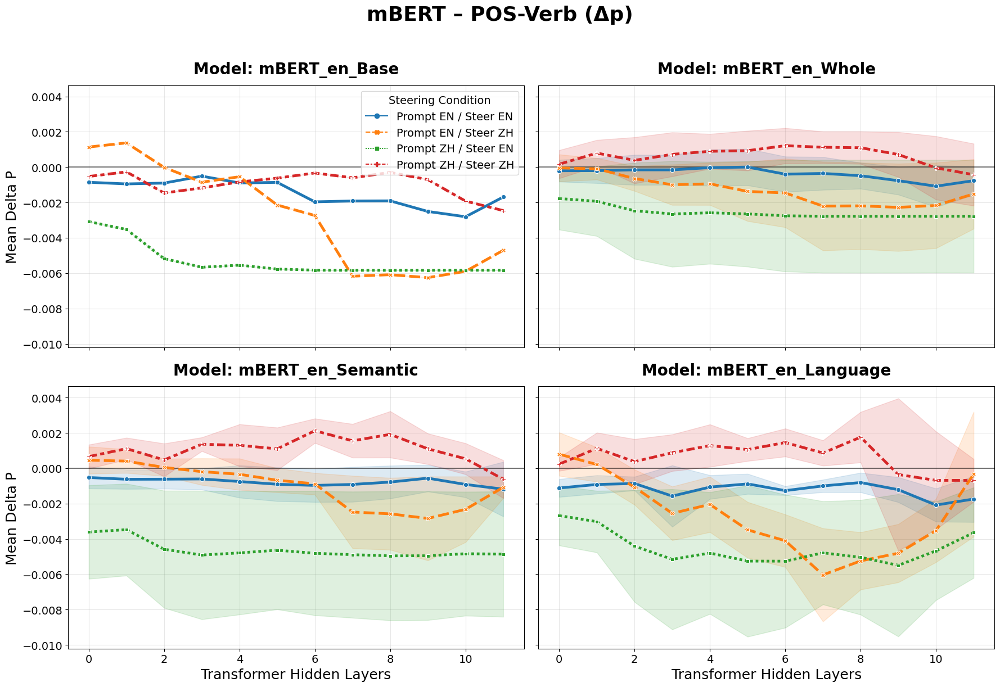

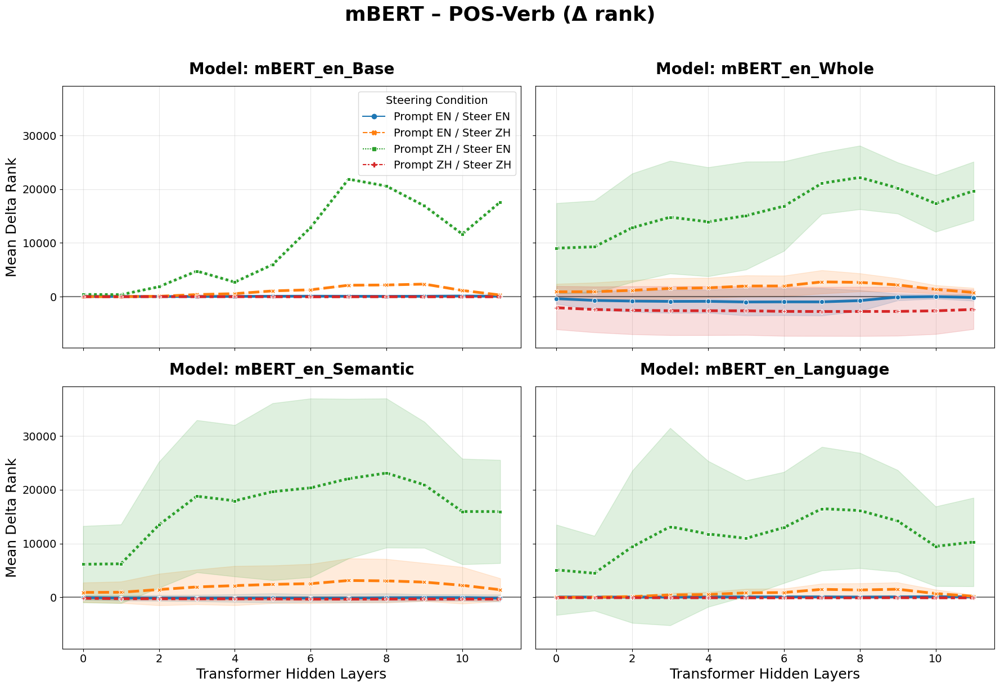

In [11]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-Verb (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      3     -0.000509
    mBERT_en_Base          en         zh      1      0.001372
    mBERT_en_Base          zh         en      0     -0.003085
    mBERT_en_Base          zh         zh      1     -0.000267
mBERT_en_Language          en         en      8     -0.000806
mBERT_en_Language          en         zh      0      0.000799
mBERT_en_Language          zh         en      0     -0.002680
mBERT_en_Language          zh         zh      8      0.001760
mBERT_en_Semantic          en         en      0     -0.000521
mBERT_en_Semantic          en         zh      0      0.000459
mBERT_en_Semantic          zh         en      1     -0.003475
mBERT_en_Semantic          zh         zh      6      0.002126
   mBERT_en_Whole          en         en      5      0.000005
   mBERT_en_Whole          en         zh      0     -0.000044
   

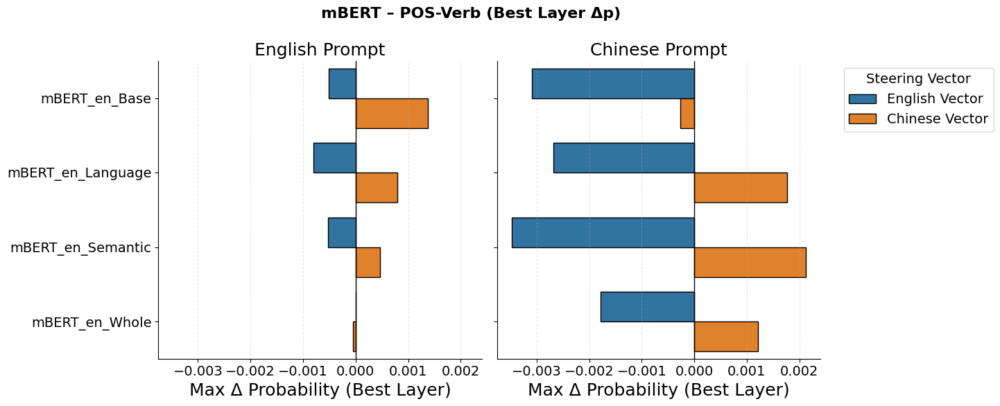

In [12]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-Verb (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en      2        16.640000
    mBERT_en_Base          en         zh      0        -7.460000
    mBERT_en_Base          zh         en      1       358.580000
    mBERT_en_Base          zh         zh      6       -40.280000
mBERT_en_Language          en         en      2        38.810000
mBERT_en_Language          en         zh      0        -4.850000
mBERT_en_Language          zh         en      1      4475.690000
mBERT_en_Language          zh         zh      6      -107.330000
mBERT_en_Semantic          en         en      4      -161.243333
mBERT_en_Semantic          en         zh      0       913.720000
mBERT_en_Semantic          zh         en      0      6146.480000
mBERT_en_Semantic          zh         zh      7      -329.483333
   mBERT_en_Whole          en         en      5      -997.786667
   mBERT_en_Whole      

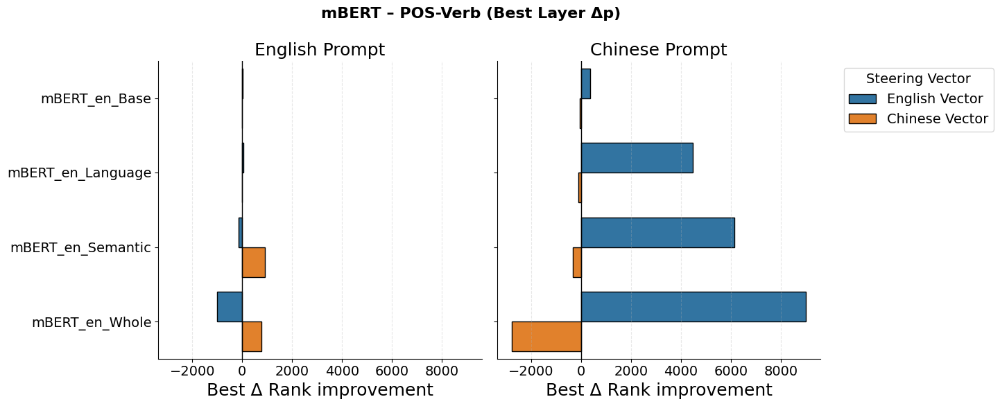

In [13]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

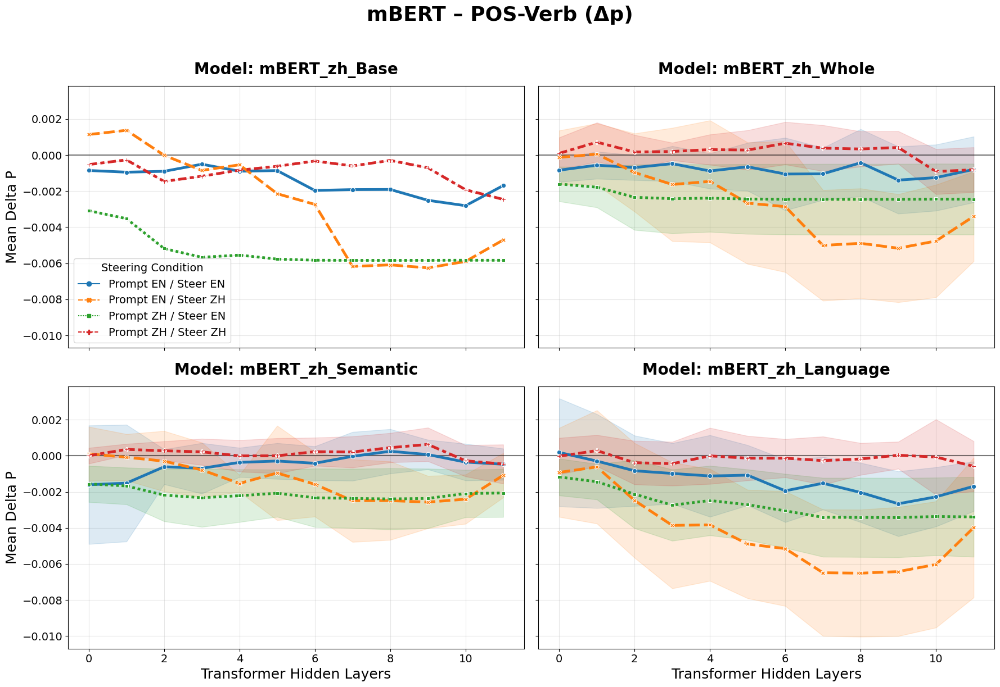

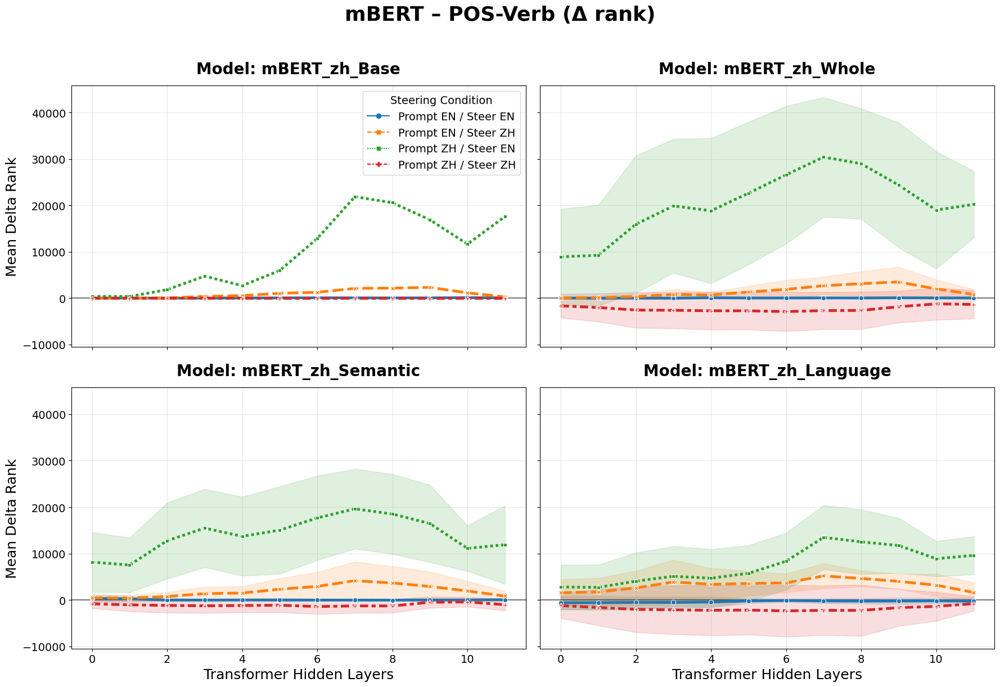

In [14]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-Verb (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      3     -0.000509
    mBERT_zh_Base          en         zh      1      0.001372
    mBERT_zh_Base          zh         en      0     -0.003085
    mBERT_zh_Base          zh         zh      1     -0.000267
mBERT_zh_Language          en         en      0      0.000182
mBERT_zh_Language          en         zh      1     -0.000621
mBERT_zh_Language          zh         en      0     -0.001181
mBERT_zh_Language          zh         zh      1      0.000285
mBERT_zh_Semantic          en         en      8      0.000247
mBERT_zh_Semantic          en         zh      0      0.000108
mBERT_zh_Semantic          zh         en      0     -0.001564
mBERT_zh_Semantic          zh         zh      9      0.000629
   mBERT_zh_Whole          en         en      8     -0.000428
   mBERT_zh_Whole          en         zh      1      0.000050
   

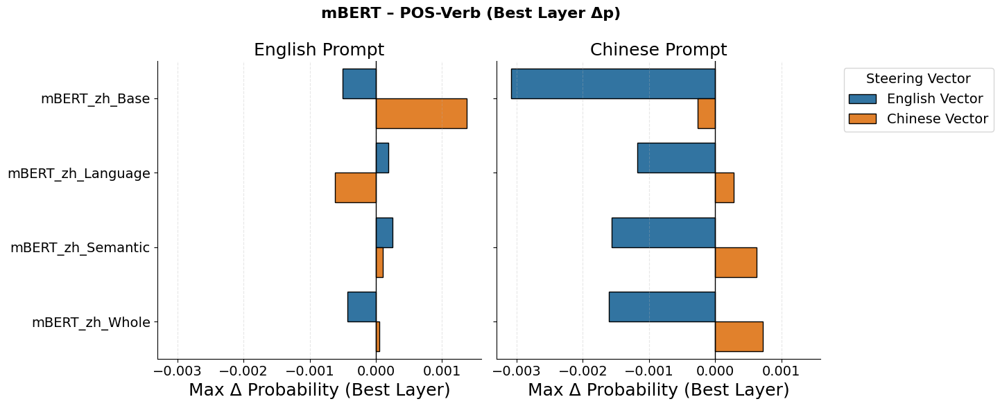

In [15]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-Verb (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en      2        16.640000
    mBERT_zh_Base          en         zh      0        -7.460000
    mBERT_zh_Base          zh         en      1       358.580000
    mBERT_zh_Base          zh         zh      6       -40.280000
mBERT_zh_Language          en         en      0      -587.313333
mBERT_zh_Language          en         zh      0      1575.550000
mBERT_zh_Language          zh         en      1      2721.486667
mBERT_zh_Language          zh         zh      6     -2350.426667
mBERT_zh_Semantic          en         en      8       -36.003333
mBERT_zh_Semantic          en         zh      1       414.126667
mBERT_zh_Semantic          zh         en      1      7529.436667
mBERT_zh_Semantic          zh         zh      6     -1411.870000
   mBERT_zh_Whole          en         en      1       -11.660000
   mBERT_zh_Whole      

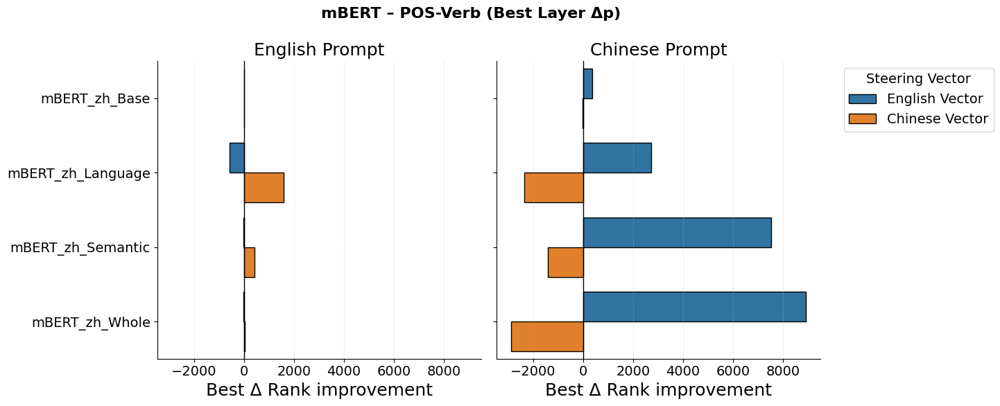

In [16]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# ADJECTIVE

In [17]:
family = "mBERT"
target = "POS-ADJ"


full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT-en

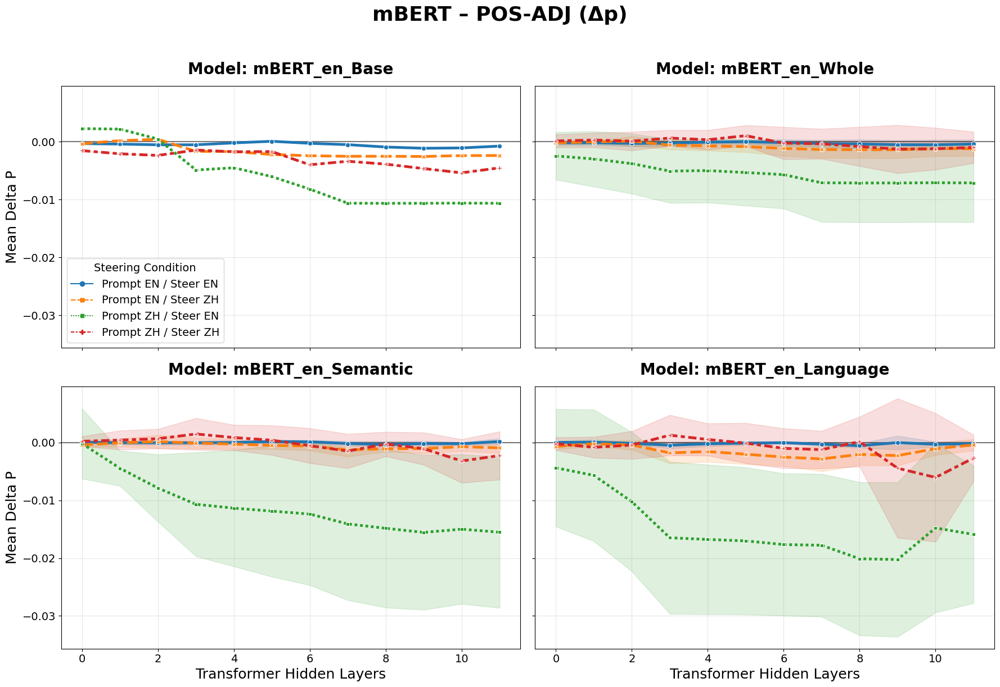

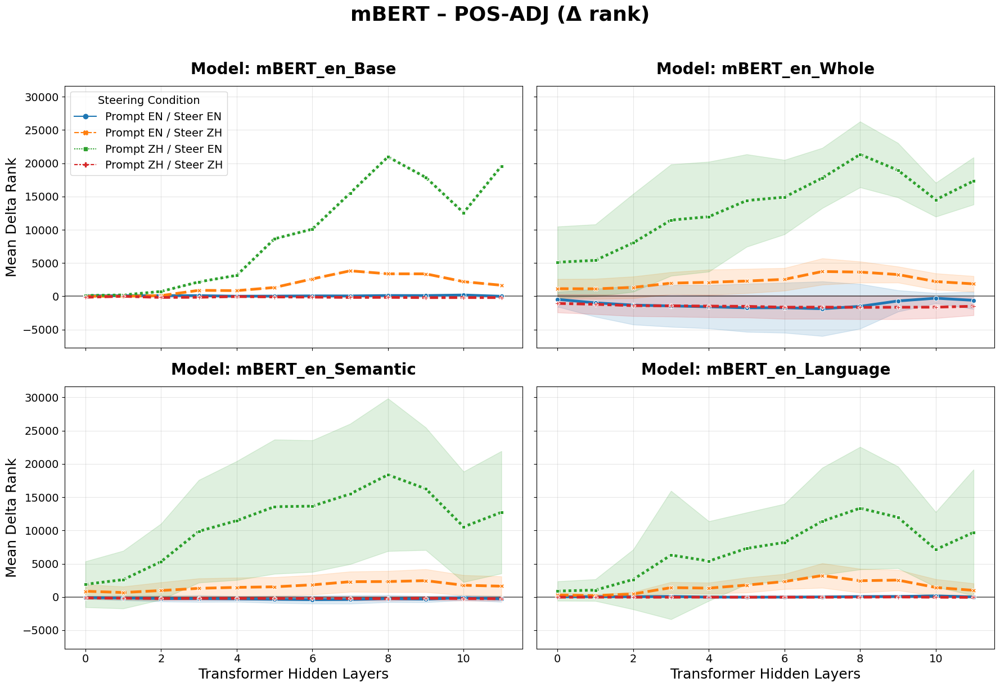

In [18]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-ADJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      5      0.000079
    mBERT_en_Base          en         zh      2      0.000415
    mBERT_en_Base          zh         en      0      0.002270
    mBERT_en_Base          zh         zh      3     -0.001438
mBERT_en_Language          en         en      1      0.000042
mBERT_en_Language          en         zh      1     -0.000227
mBERT_en_Language          zh         en      0     -0.004389
mBERT_en_Language          zh         zh      3      0.001256
mBERT_en_Semantic          en         en     11      0.000158
mBERT_en_Semantic          en         zh      2      0.000142
mBERT_en_Semantic          zh         en      0     -0.000198
mBERT_en_Semantic          zh         zh      3      0.001462
   mBERT_en_Whole          en         en      5      0.000007
   mBERT_en_Whole          en         zh      2      0.000112
   m

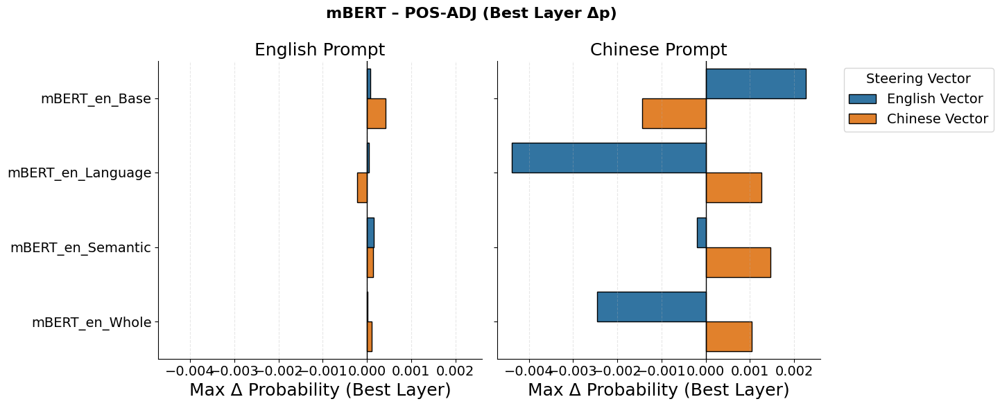

In [19]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-ADJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en     11         3.460000
    mBERT_en_Base          en         zh      1        13.240000
    mBERT_en_Base          zh         en      0       125.393333
    mBERT_en_Base          zh         zh      9      -197.640000
mBERT_en_Language          en         en      5       -23.970000
mBERT_en_Language          en         zh      1       215.166667
mBERT_en_Language          zh         en      0       892.586667
mBERT_en_Language          zh         zh     11       -57.316667
mBERT_en_Semantic          en         en      6      -403.300000
mBERT_en_Semantic          en         zh      1       674.663333
mBERT_en_Semantic          zh         en      0      1905.113333
mBERT_en_Semantic          zh         zh     11      -255.123333
   mBERT_en_Whole          en         en      7     -1869.370000
   mBERT_en_Whole       

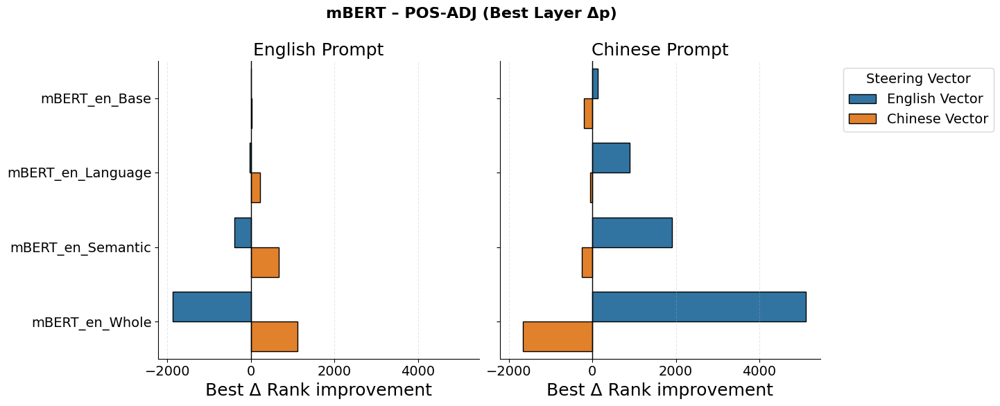

In [20]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

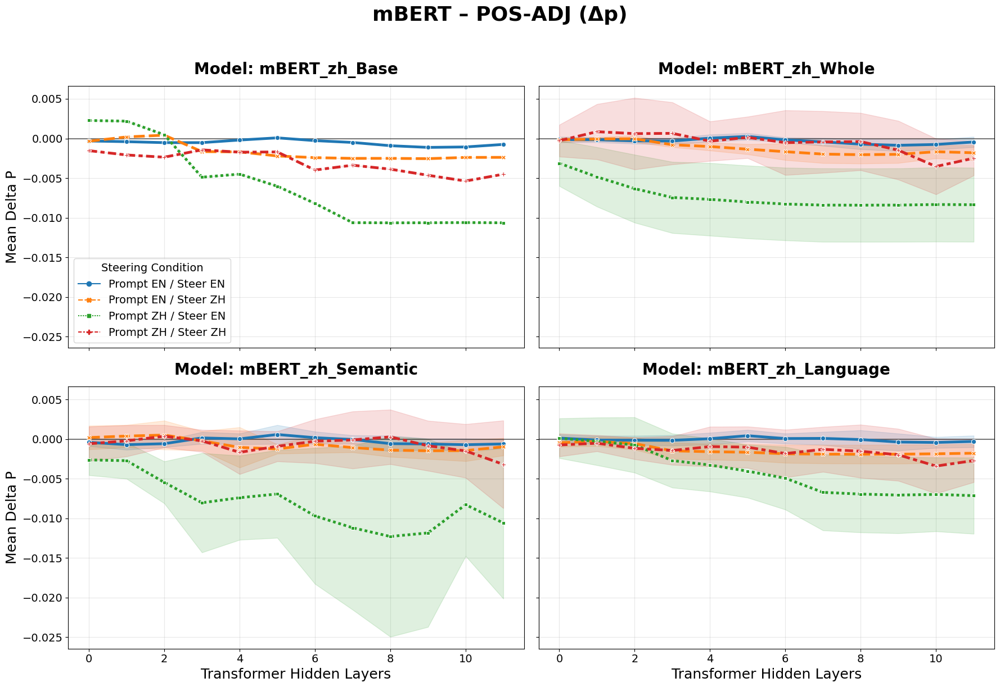

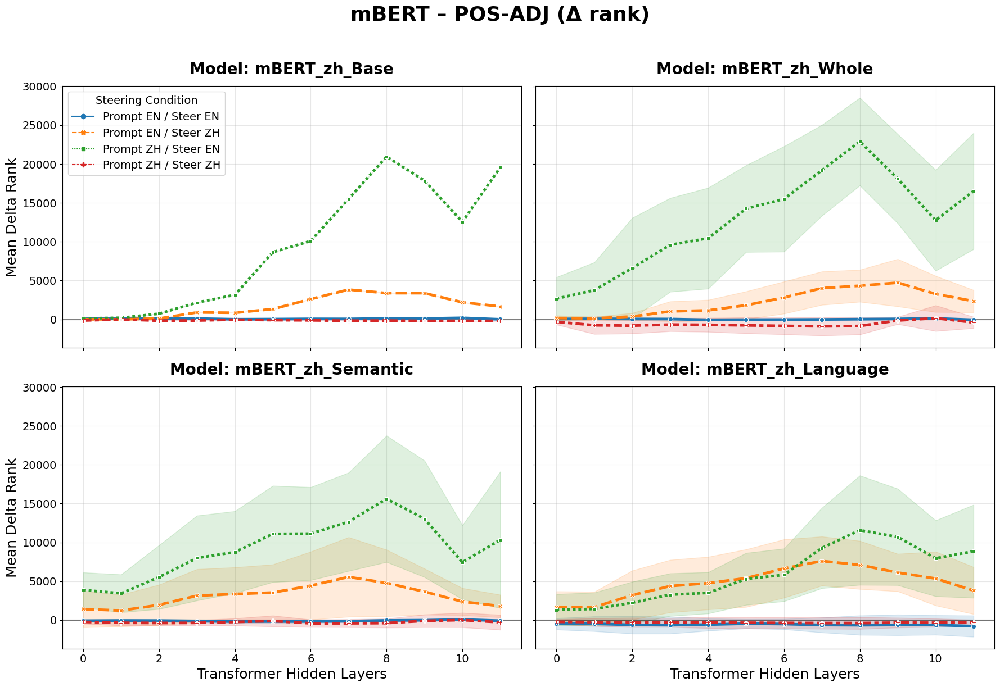

In [21]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-ADJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      5      0.000079
    mBERT_zh_Base          en         zh      2      0.000415
    mBERT_zh_Base          zh         en      0      0.002270
    mBERT_zh_Base          zh         zh      3     -0.001438
mBERT_zh_Language          en         en      5      0.000437
mBERT_zh_Language          en         zh      1     -0.000285
mBERT_zh_Language          zh         en      0      0.000116
mBERT_zh_Language          zh         zh      1     -0.000514
mBERT_zh_Semantic          en         en      5      0.000587
mBERT_zh_Semantic          en         zh      2      0.000517
mBERT_zh_Semantic          zh         en      0     -0.002621
mBERT_zh_Semantic          zh         zh      2      0.000366
   mBERT_zh_Whole          en         en      5      0.000255
   mBERT_zh_Whole          en         zh      2     -0.000033
   m

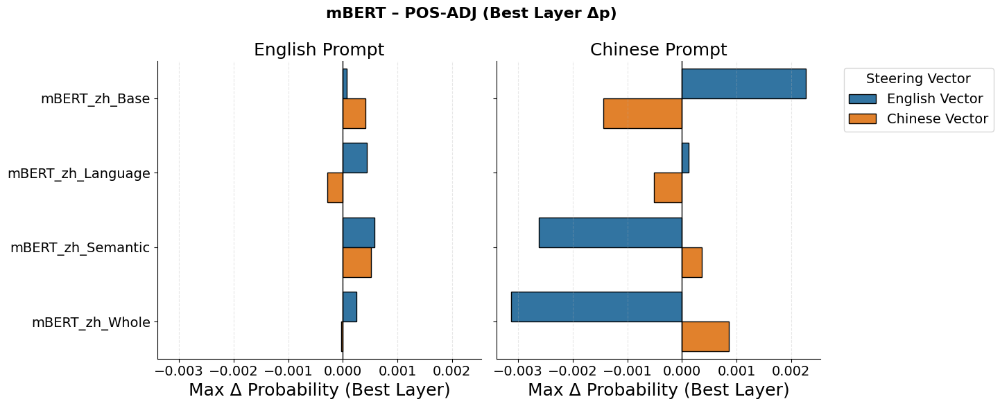

In [22]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-ADJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en     11         3.460000
    mBERT_zh_Base          en         zh      1        13.240000
    mBERT_zh_Base          zh         en      0       125.393333
    mBERT_zh_Base          zh         zh      9      -197.640000
mBERT_zh_Language          en         en     11      -781.470000
mBERT_zh_Language          en         zh      1      1668.626667
mBERT_zh_Language          zh         en      0      1322.066667
mBERT_zh_Language          zh         zh      8      -382.263333
mBERT_zh_Semantic          en         en      4      -193.306667
mBERT_zh_Semantic          en         zh      1      1230.066667
mBERT_zh_Semantic          zh         en      1      3437.270000
mBERT_zh_Semantic          zh         zh      6      -417.136667
   mBERT_zh_Whole          en         en      4       -56.183333
   mBERT_zh_Whole       

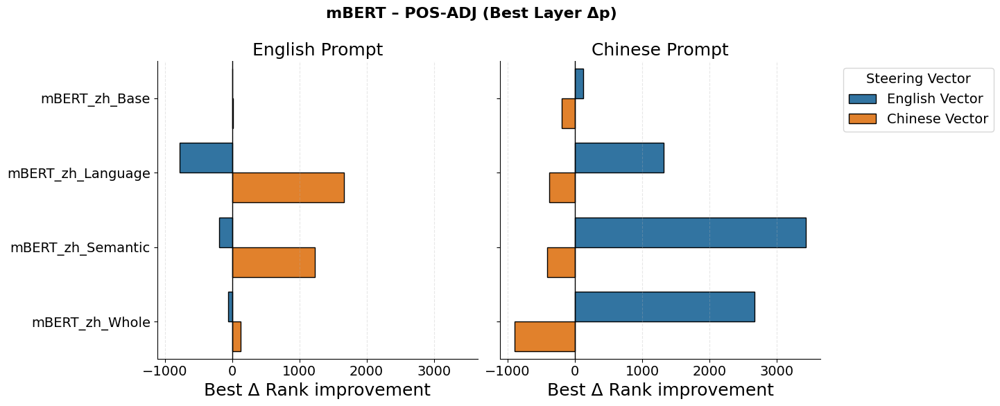

In [23]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# PRONOUNS

In [24]:
family = "mBERT"
target = "POS-PRON"


full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT-en

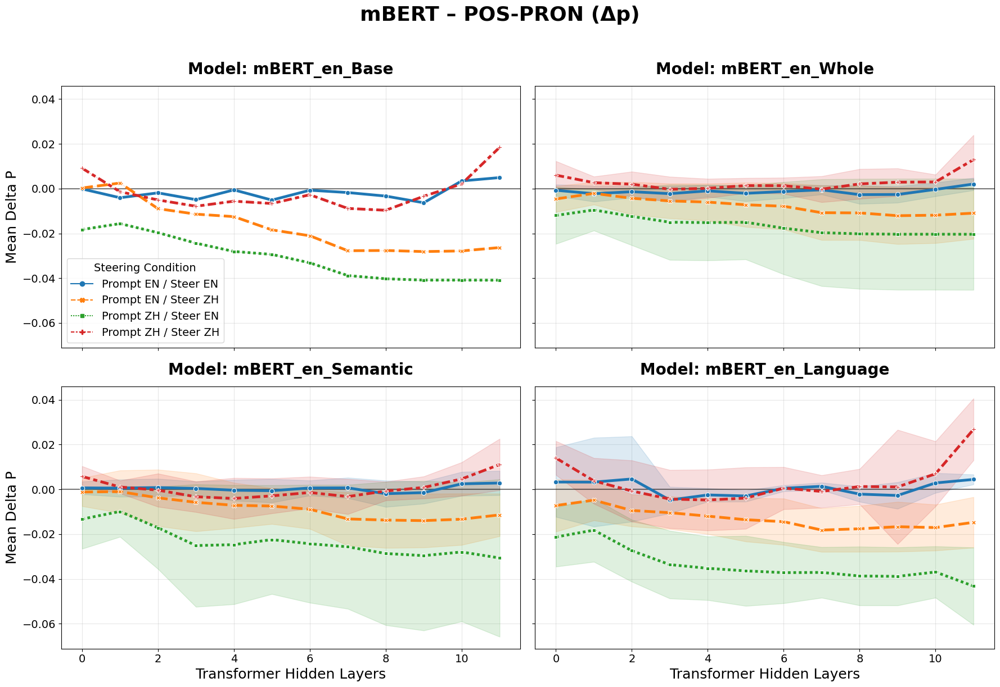

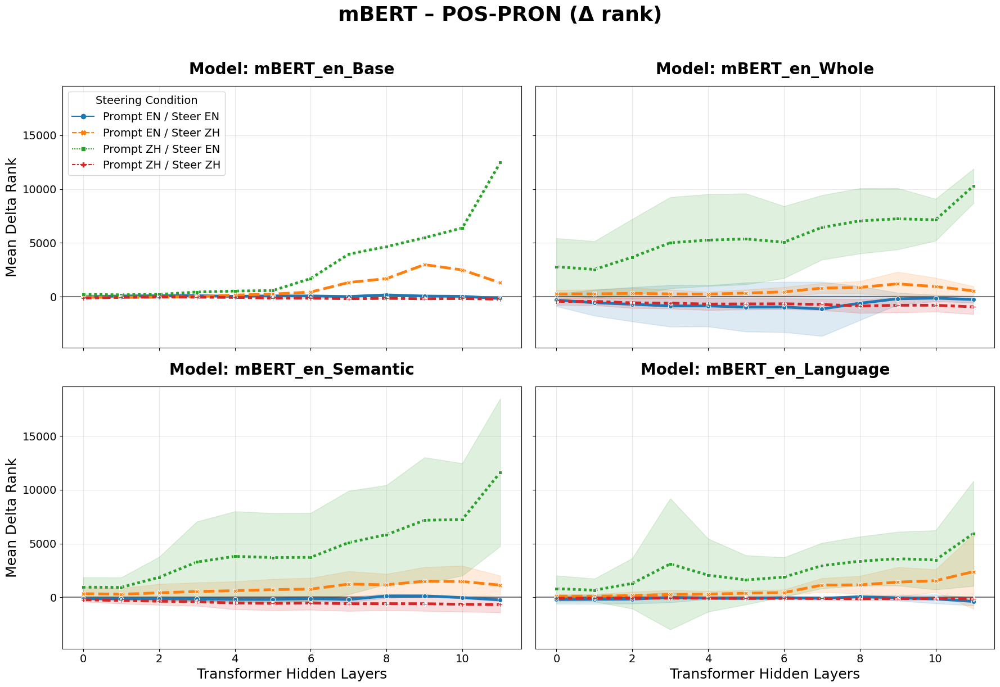

In [25]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-PRON (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en     11      0.004921
    mBERT_en_Base          en         zh      1      0.002489
    mBERT_en_Base          zh         en      1     -0.015630
    mBERT_en_Base          zh         zh     11      0.018425
mBERT_en_Language          en         en      2      0.004618
mBERT_en_Language          en         zh      1     -0.004846
mBERT_en_Language          zh         en      1     -0.018237
mBERT_en_Language          zh         zh     11      0.026769
mBERT_en_Semantic          en         en     11      0.002811
mBERT_en_Semantic          en         zh      1     -0.001035
mBERT_en_Semantic          zh         en      1     -0.009902
mBERT_en_Semantic          zh         zh     11      0.011073
   mBERT_en_Whole          en         en     11      0.002049
   mBERT_en_Whole          en         zh      1     -0.002121
   

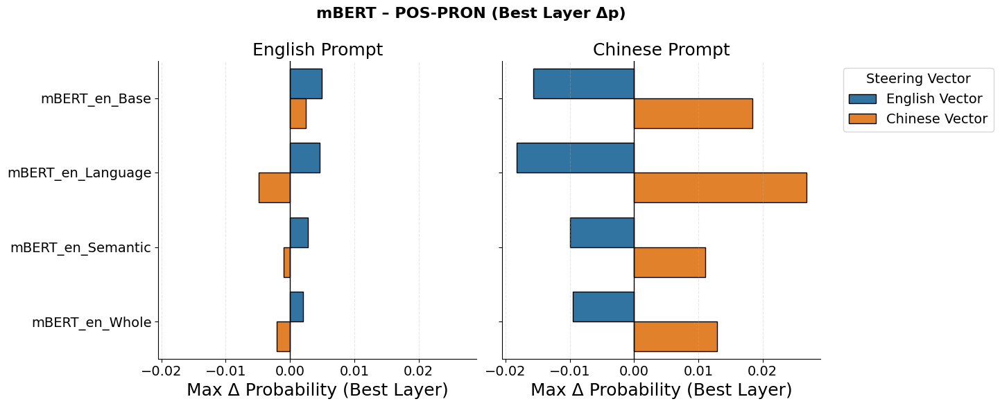

In [26]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-PRON (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en     11      -162.540000
    mBERT_en_Base          en         zh      1       -50.820000
    mBERT_en_Base          zh         en      1       178.640000
    mBERT_en_Base          zh         zh     11      -229.660000
mBERT_en_Language          en         en     11      -375.526667
mBERT_en_Language          en         zh      1       107.756667
mBERT_en_Language          zh         en      1       670.106667
mBERT_en_Language          zh         zh     11      -141.106667
mBERT_en_Semantic          en         en     11      -234.650000
mBERT_en_Semantic          en         zh      1       291.106667
mBERT_en_Semantic          zh         en      1       931.140000
mBERT_en_Semantic          zh         zh     11      -677.213333
   mBERT_en_Whole          en         en      7     -1138.150000
   mBERT_en_Whole      

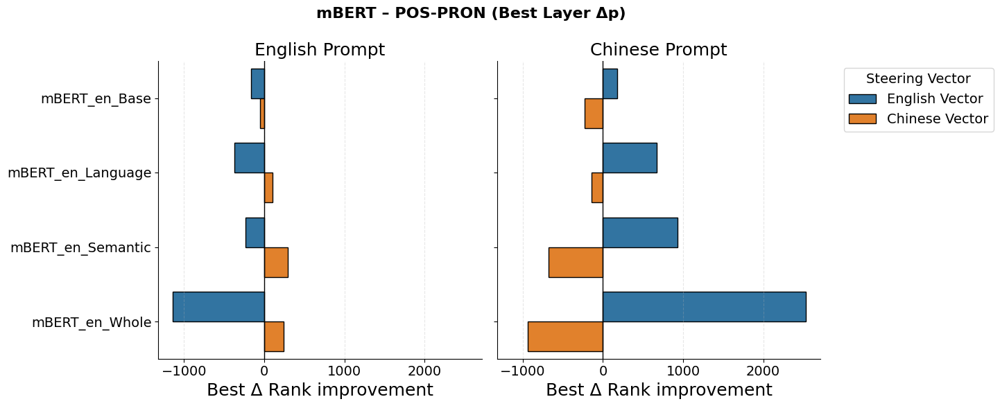

In [27]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

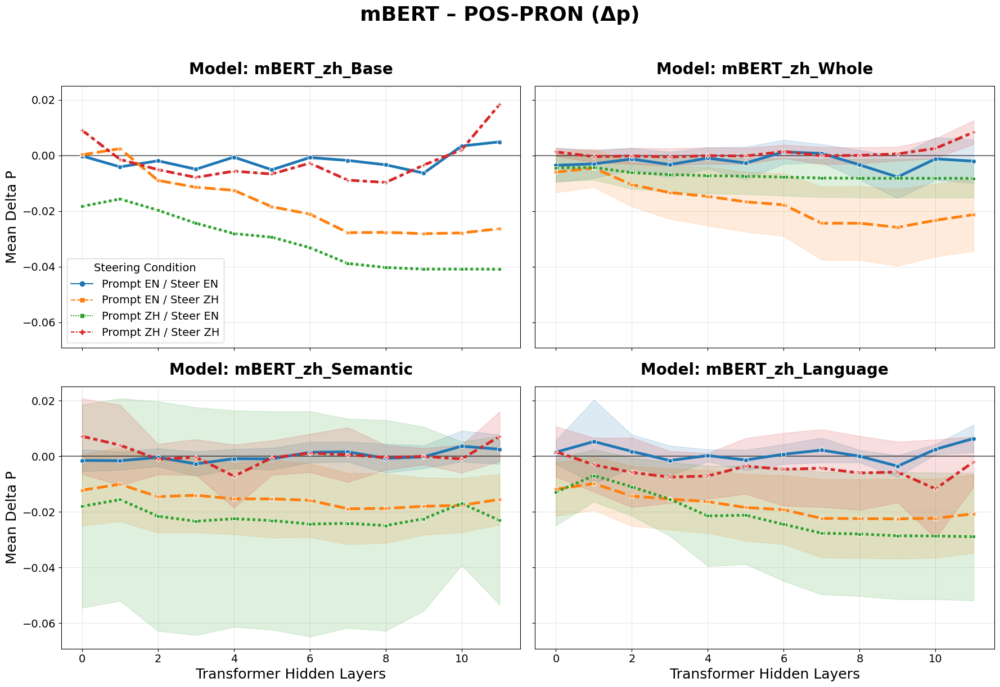

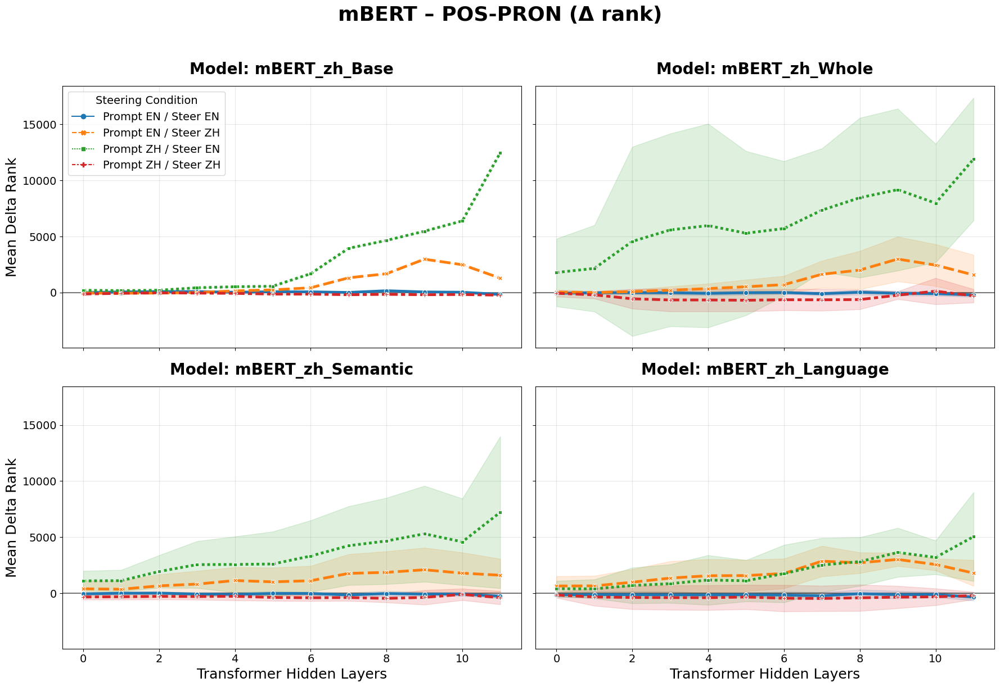

In [28]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-PRON (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en     11      0.004921
    mBERT_zh_Base          en         zh      1      0.002489
    mBERT_zh_Base          zh         en      1     -0.015630
    mBERT_zh_Base          zh         zh     11      0.018425
mBERT_zh_Language          en         en     11      0.006371
mBERT_zh_Language          en         zh      1     -0.009821
mBERT_zh_Language          zh         en      1     -0.006958
mBERT_zh_Language          zh         zh      0      0.001656
mBERT_zh_Semantic          en         en     10      0.003612
mBERT_zh_Semantic          en         zh      1     -0.010080
mBERT_zh_Semantic          zh         en      1     -0.015614
mBERT_zh_Semantic          zh         zh      0      0.007175
   mBERT_zh_Whole          en         en      6      0.001309
   mBERT_zh_Whole          en         zh      1     -0.004501
   

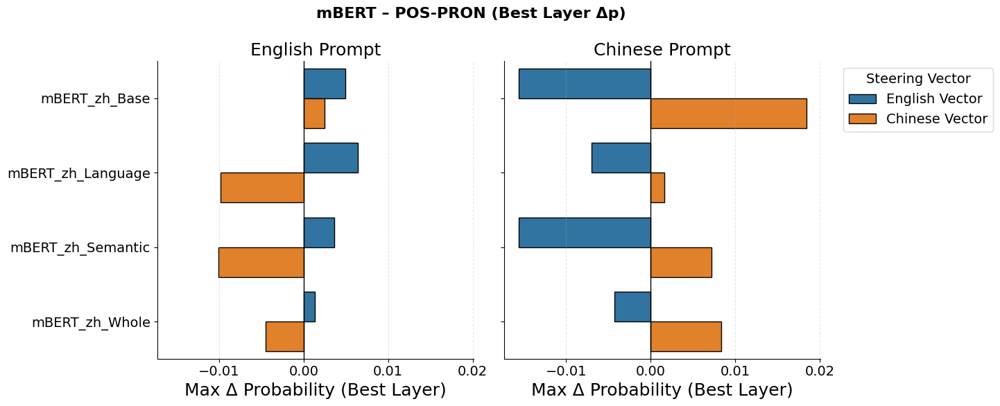

In [29]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-PRON (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en     11      -162.540000
    mBERT_zh_Base          en         zh      1       -50.820000
    mBERT_zh_Base          zh         en      1       178.640000
    mBERT_zh_Base          zh         zh     11      -229.660000
mBERT_zh_Language          en         en     11      -335.733333
mBERT_zh_Language          en         zh      0       653.066667
mBERT_zh_Language          zh         en      1       396.600000
mBERT_zh_Language          zh         zh      7      -457.686667
mBERT_zh_Semantic          en         en     11      -258.850000
mBERT_zh_Semantic          en         zh      1       361.856667
mBERT_zh_Semantic          zh         en      0      1107.156667
mBERT_zh_Semantic          zh         zh      8      -451.780000
   mBERT_zh_Whole          en         en     11      -205.906667
   mBERT_zh_Whole      

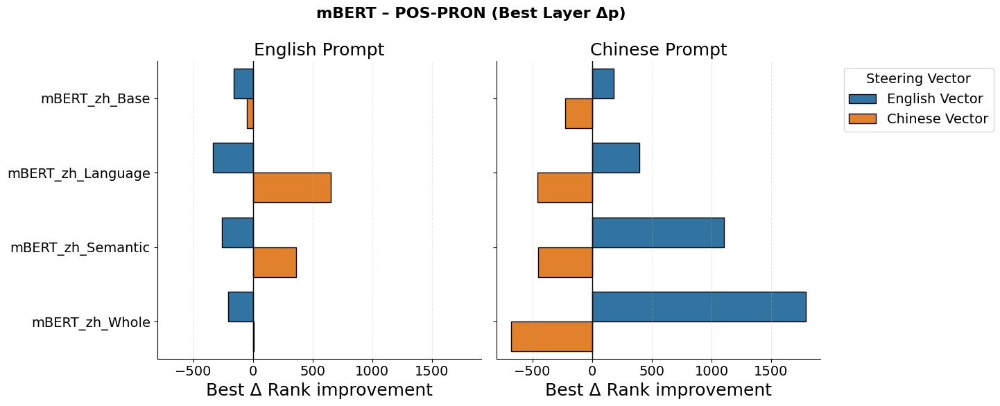

In [30]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# ADPOSITIONS

In [31]:
family = "mBERT"
target = "POS-ADP"


full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT-en

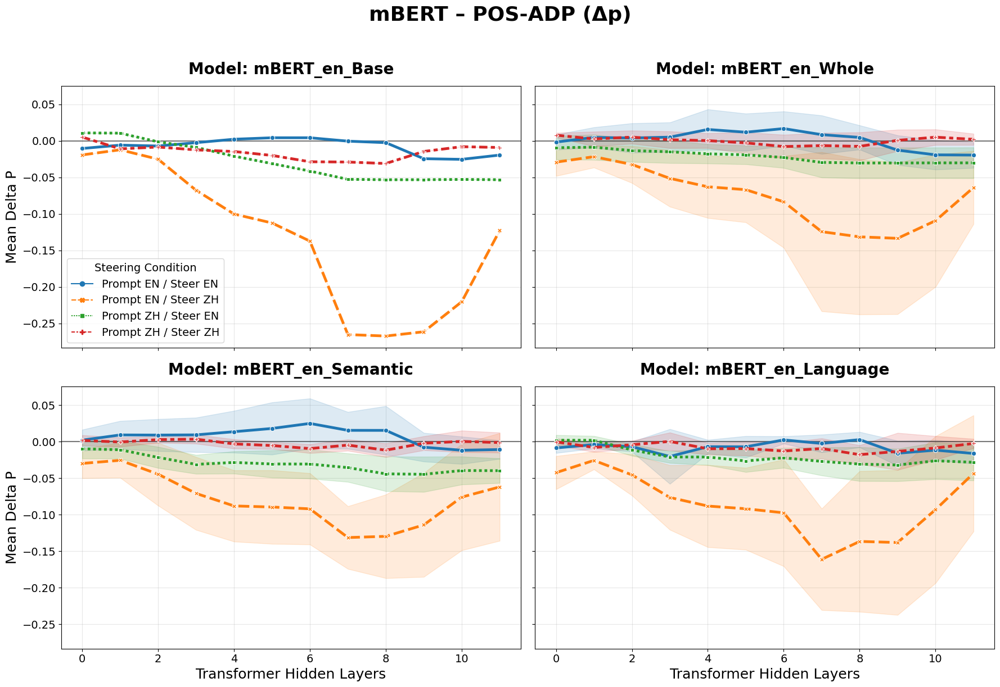

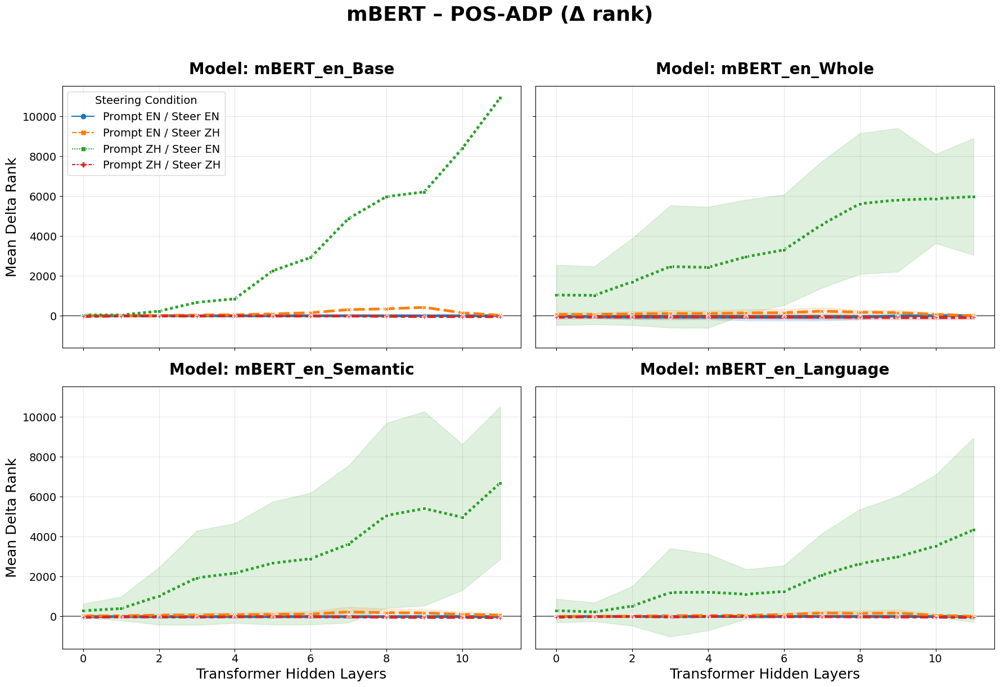

In [32]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-ADP (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      6      0.004421
    mBERT_en_Base          en         zh      1     -0.012052
    mBERT_en_Base          zh         en      0      0.011057
    mBERT_en_Base          zh         zh      0      0.005365
mBERT_en_Language          en         en      8      0.002823
mBERT_en_Language          en         zh      1     -0.025652
mBERT_en_Language          zh         en      0      0.001968
mBERT_en_Language          zh         zh      3      0.000357
mBERT_en_Semantic          en         en      6      0.024974
mBERT_en_Semantic          en         zh      1     -0.025513
mBERT_en_Semantic          zh         en      0     -0.009755
mBERT_en_Semantic          zh         zh      3      0.003443
   mBERT_en_Whole          en         en      6      0.016997
   mBERT_en_Whole          en         zh      1     -0.021486
   m

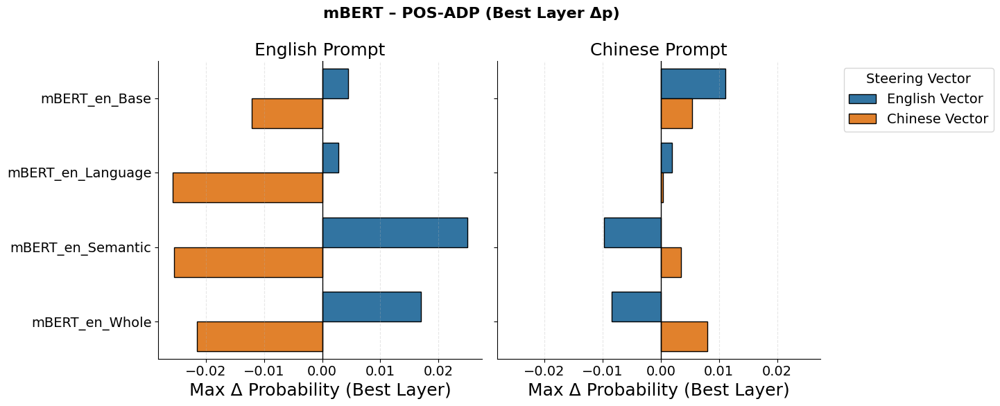

In [33]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-ADP (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en     10        -1.280000
    mBERT_en_Base          en         zh      0         2.660000
    mBERT_en_Base          zh         en      1        37.920000
    mBERT_en_Base          zh         zh     11       -46.880000
mBERT_en_Language          en         en     10        -1.373333
mBERT_en_Language          en         zh      1         7.903333
mBERT_en_Language          zh         en      1       226.263333
mBERT_en_Language          zh         zh     11       -52.260000
mBERT_en_Semantic          en         en      7        -9.090000
mBERT_en_Semantic          en         zh      0        30.193333
mBERT_en_Semantic          zh         en      0       285.406667
mBERT_en_Semantic          zh         zh     11       -62.903333
   mBERT_en_Whole          en         en      7       -76.893333
   mBERT_en_Whole       

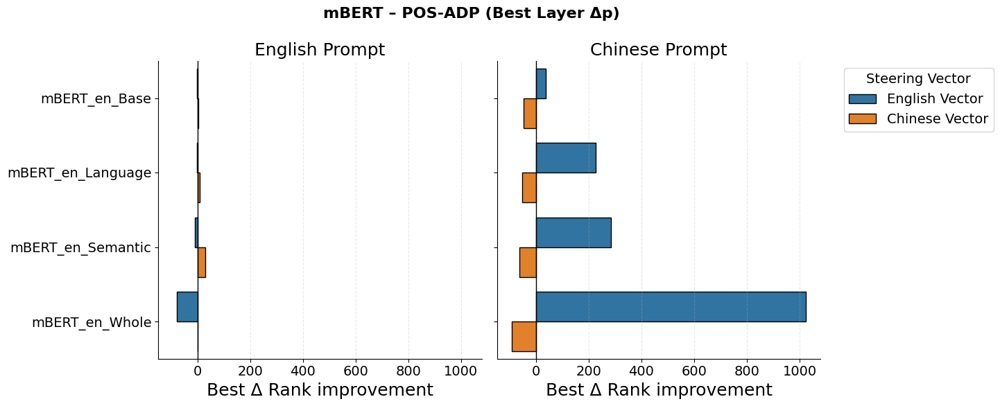

In [34]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

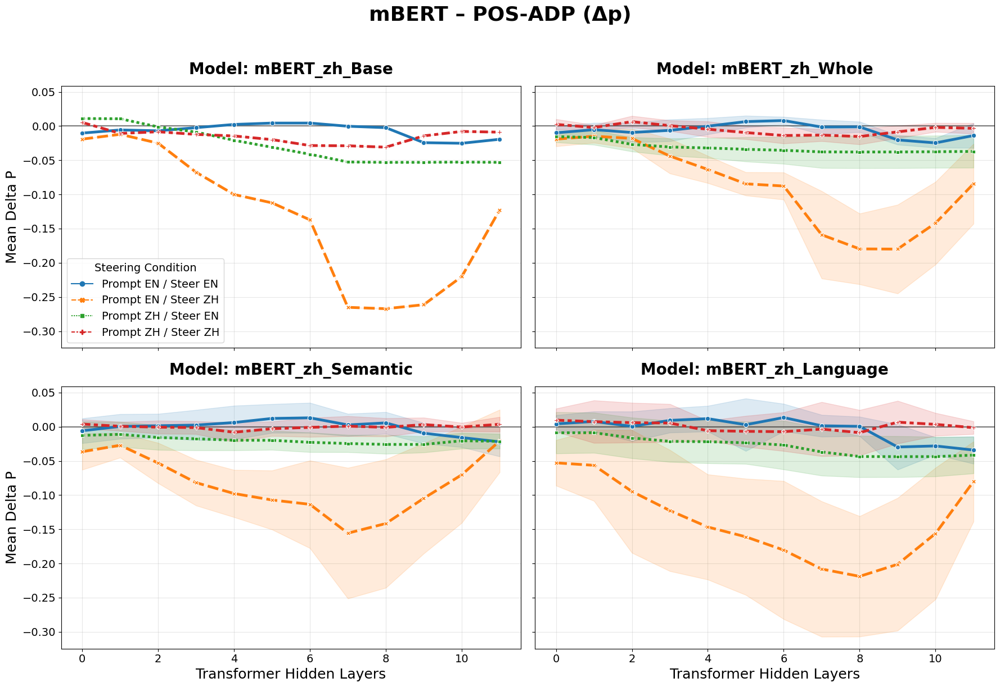

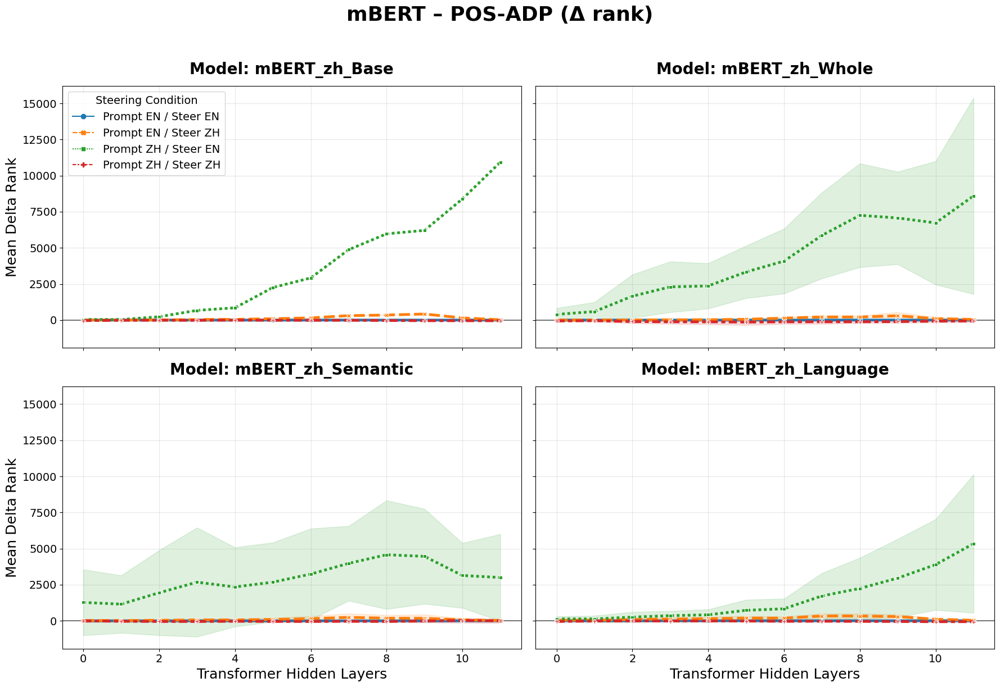

In [35]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-ADP (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      6      0.004421
    mBERT_zh_Base          en         zh      1     -0.012052
    mBERT_zh_Base          zh         en      0      0.011057
    mBERT_zh_Base          zh         zh      0      0.005365
mBERT_zh_Language          en         en      6      0.013507
mBERT_zh_Language          en         zh      0     -0.052744
mBERT_zh_Language          zh         en      1     -0.008681
mBERT_zh_Language          zh         zh      0      0.009706
mBERT_zh_Semantic          en         en      6      0.013116
mBERT_zh_Semantic          en         zh     11     -0.020682
mBERT_zh_Semantic          zh         en      1     -0.011055
mBERT_zh_Semantic          zh         zh      0      0.004001
   mBERT_zh_Whole          en         en      6      0.008112
   mBERT_zh_Whole          en         zh      1     -0.014782
   m

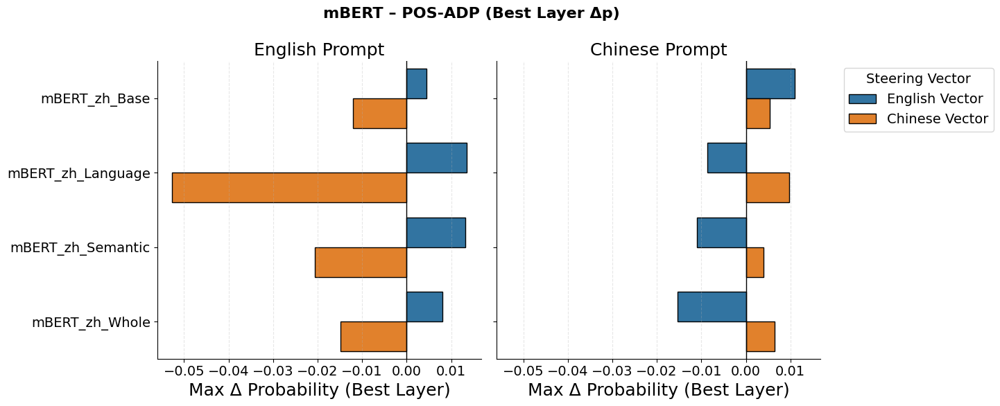

In [36]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-ADP (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en     10        -1.280000
    mBERT_zh_Base          en         zh      0         2.660000
    mBERT_zh_Base          zh         en      1        37.920000
    mBERT_zh_Base          zh         zh     11       -46.880000
mBERT_zh_Language          en         en      1        -2.260000
mBERT_zh_Language          en         zh     11        33.170000
mBERT_zh_Language          zh         en      1       128.240000
mBERT_zh_Language          zh         zh     10       -63.776667
mBERT_zh_Semantic          en         en      9        -5.156667
mBERT_zh_Semantic          en         zh      1        14.920000
mBERT_zh_Semantic          zh         en      1      1151.866667
mBERT_zh_Semantic          zh         zh      8       -51.086667
   mBERT_zh_Whole          en         en      1        -1.010000
   mBERT_zh_Whole       

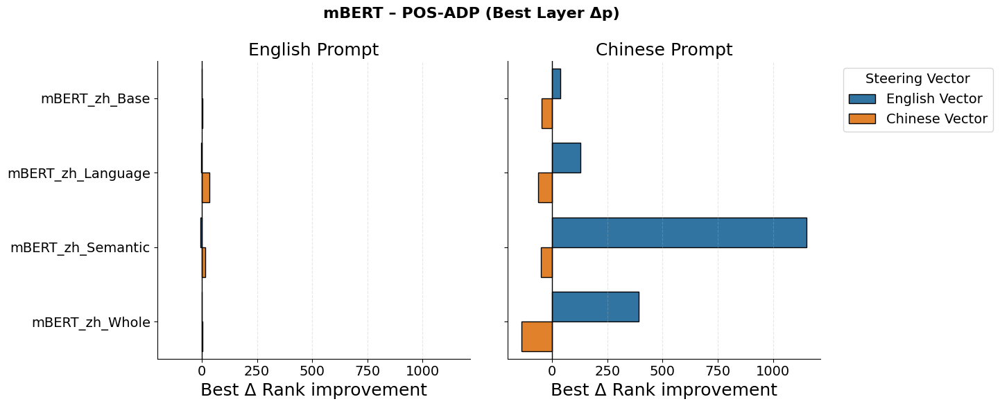

In [37]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# DETERMINERS

In [38]:
family = "mBERT"
target = "POS-DET"


full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT-en

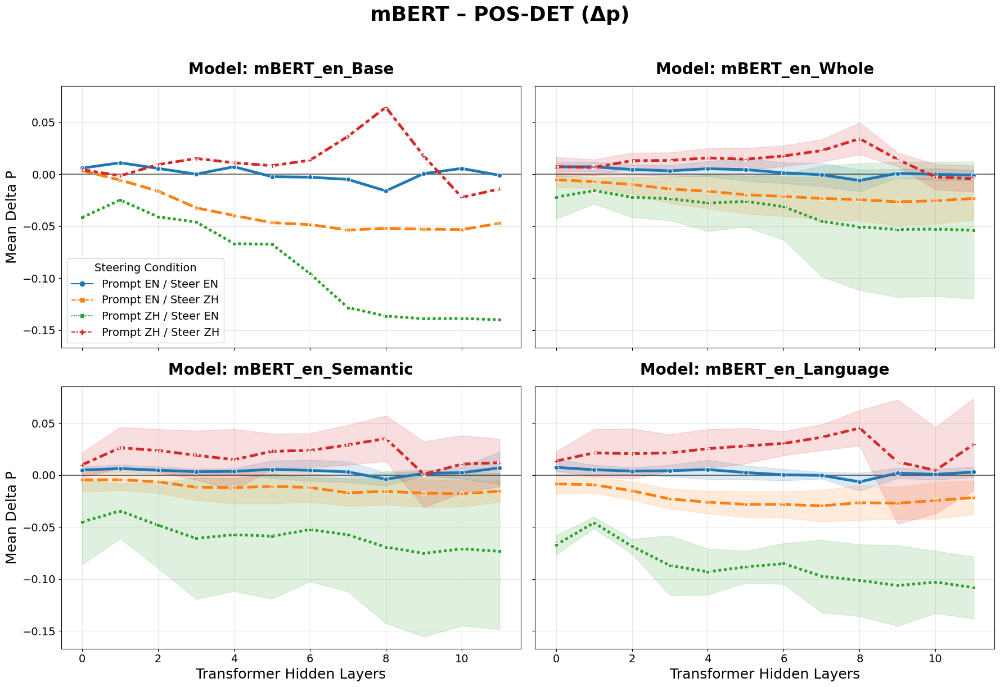

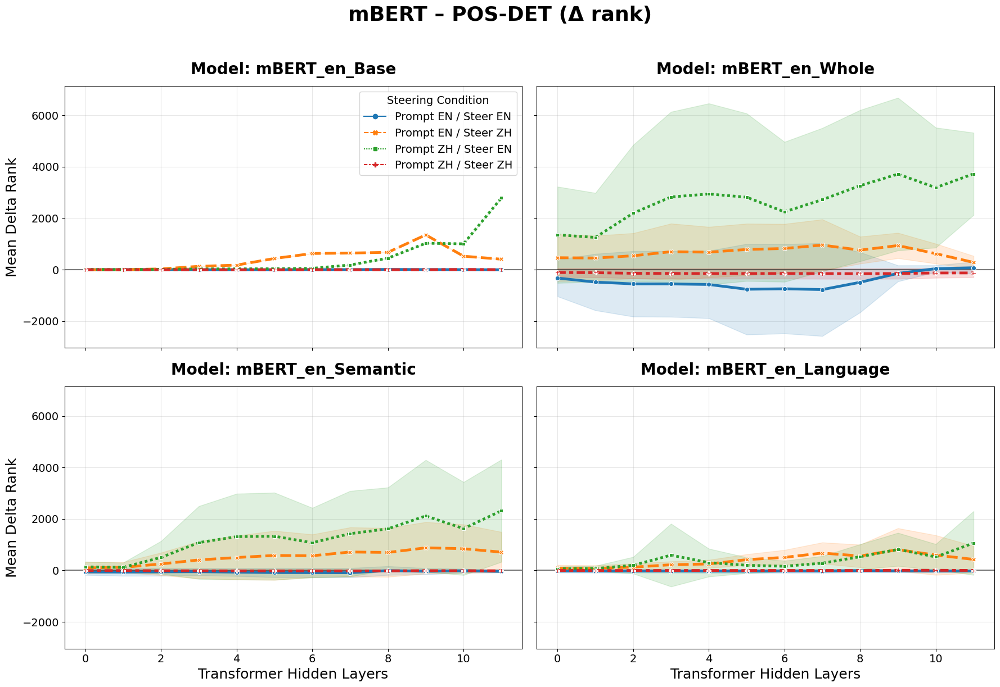

In [39]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-DET (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      1      0.011142
    mBERT_en_Base          en         zh      0      0.003512
    mBERT_en_Base          zh         en      1     -0.024714
    mBERT_en_Base          zh         zh      8      0.064577
mBERT_en_Language          en         en      0      0.007399
mBERT_en_Language          en         zh      0     -0.008502
mBERT_en_Language          zh         en      1     -0.045938
mBERT_en_Language          zh         zh      8      0.045208
mBERT_en_Semantic          en         en     11      0.006856
mBERT_en_Semantic          en         zh      1     -0.004550
mBERT_en_Semantic          zh         en      1     -0.034559
mBERT_en_Semantic          zh         zh      8      0.035185
   mBERT_en_Whole          en         en      1      0.007271
   mBERT_en_Whole          en         zh      0     -0.005169
   m

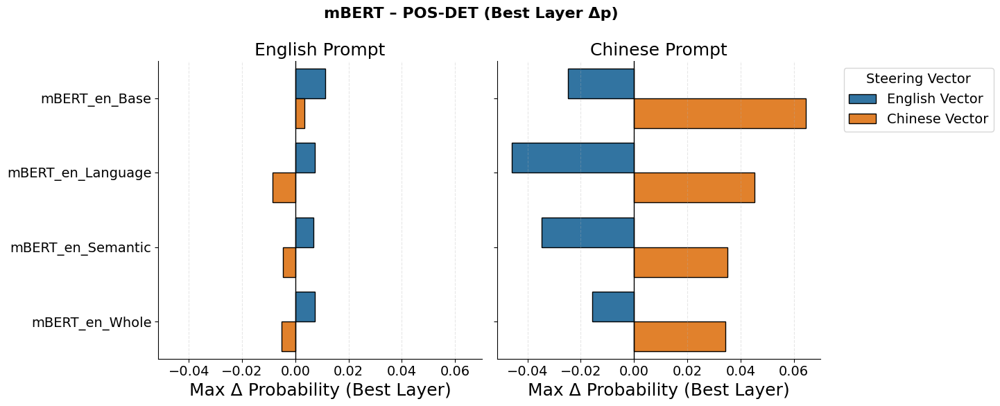

In [40]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-DET (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en     11        -2.960000
    mBERT_en_Base          en         zh      0        -2.380000
    mBERT_en_Base          zh         en      1         3.760000
    mBERT_en_Base          zh         zh      5        -3.220000
mBERT_en_Language          en         en      5       -29.906667
mBERT_en_Language          en         zh      1        77.303333
mBERT_en_Language          zh         en      0        60.090000
mBERT_en_Language          zh         zh      5        -4.833333
mBERT_en_Semantic          en         en      7       -91.036667
mBERT_en_Semantic          en         zh      0        97.950000
mBERT_en_Semantic          zh         en      1       119.276667
mBERT_en_Semantic          zh         zh      8       -20.863333
   mBERT_en_Whole          en         en      7      -773.523333
   mBERT_en_Whole       

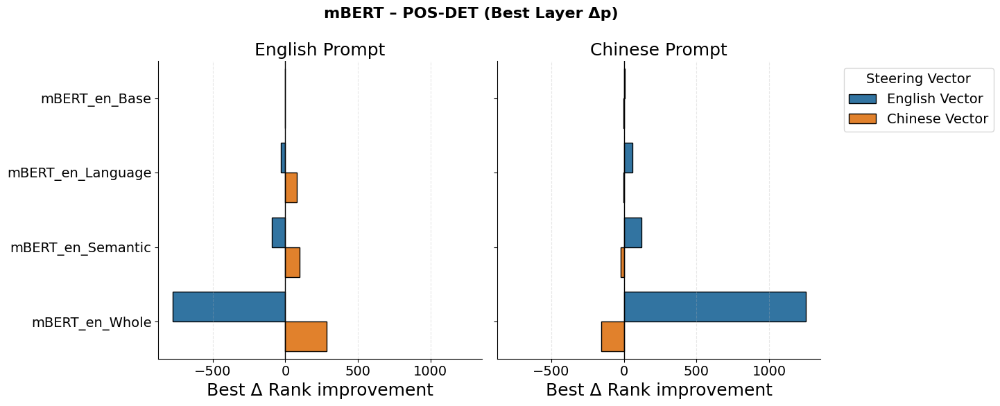

In [41]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

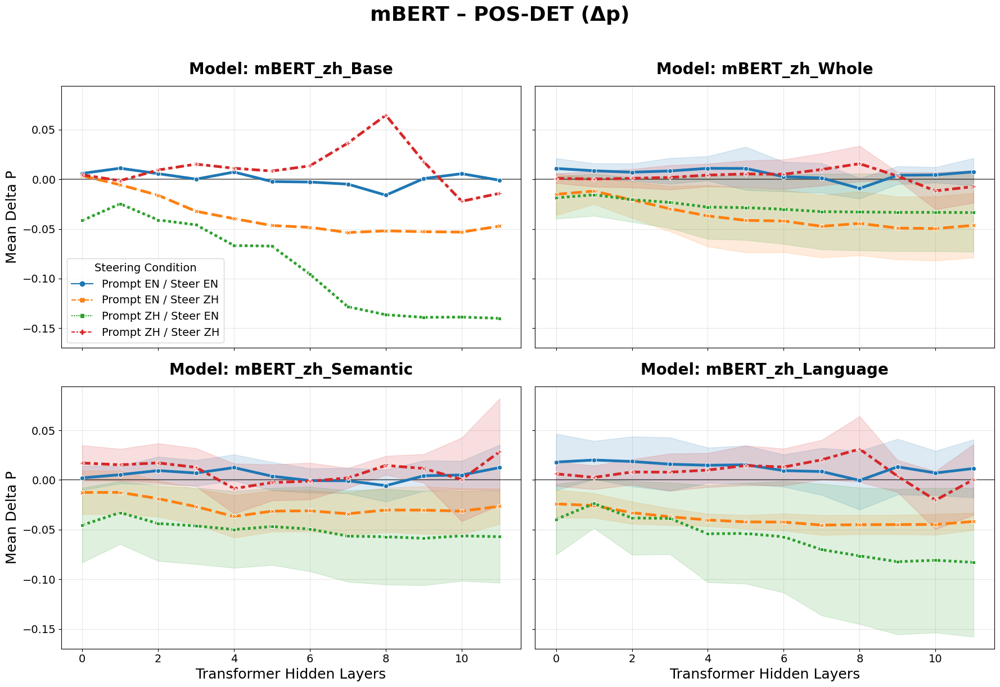

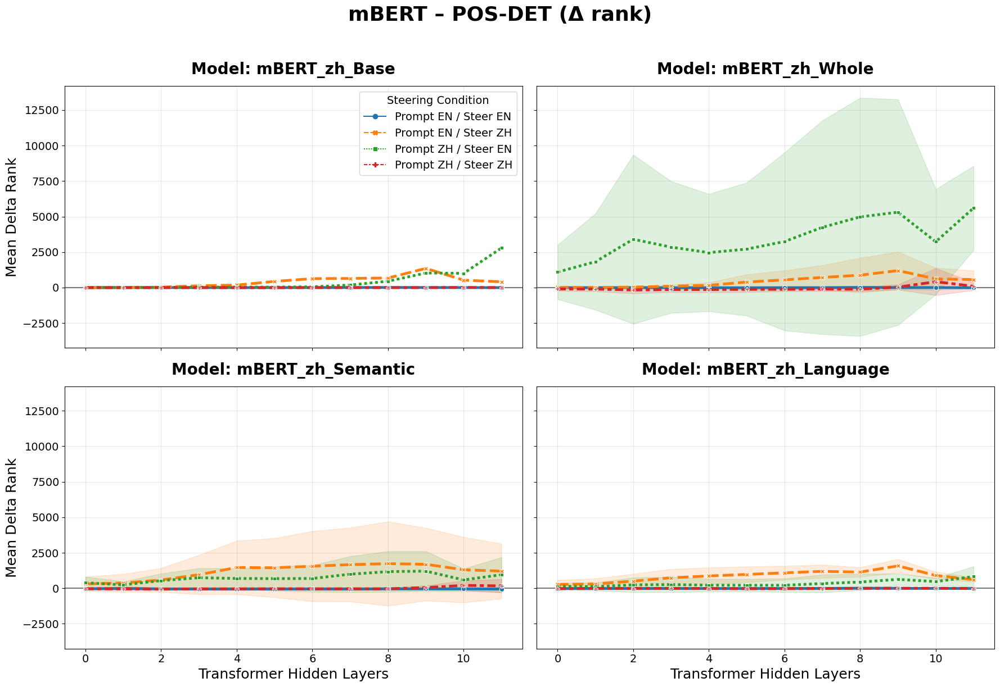

In [42]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-DET (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      1      0.011142
    mBERT_zh_Base          en         zh      0      0.003512
    mBERT_zh_Base          zh         en      1     -0.024714
    mBERT_zh_Base          zh         zh      8      0.064577
mBERT_zh_Language          en         en      1      0.020099
mBERT_zh_Language          en         zh      0     -0.024059
mBERT_zh_Language          zh         en      1     -0.023775
mBERT_zh_Language          zh         zh      8      0.031168
mBERT_zh_Semantic          en         en     11      0.012497
mBERT_zh_Semantic          en         zh      1     -0.012495
mBERT_zh_Semantic          zh         en      1     -0.032845
mBERT_zh_Semantic          zh         zh     11      0.028504
   mBERT_zh_Whole          en         en      4      0.011035
   mBERT_zh_Whole          en         zh      1     -0.011881
   m

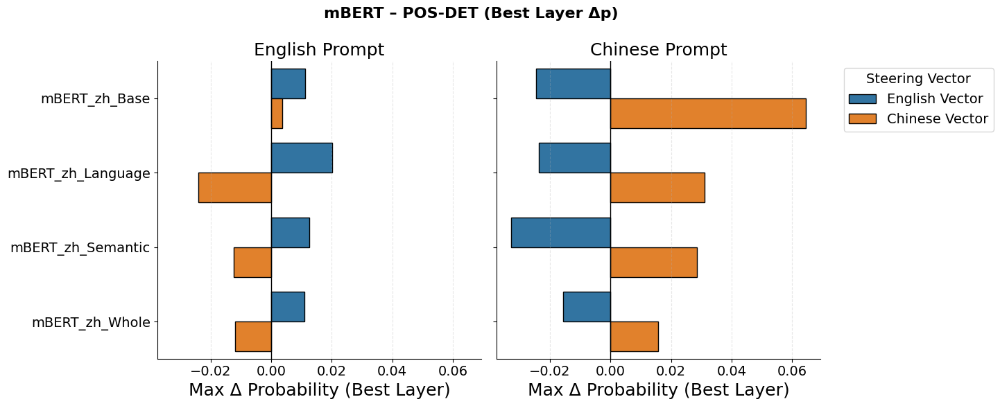

In [43]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-DET (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en     11        -2.960000
    mBERT_zh_Base          en         zh      0        -2.380000
    mBERT_zh_Base          zh         en      1         3.760000
    mBERT_zh_Base          zh         zh      5        -3.220000
mBERT_zh_Language          en         en     11       -15.436667
mBERT_zh_Language          en         zh      0       267.883333
mBERT_zh_Language          zh         en      1       119.926667
mBERT_zh_Language          zh         zh      0       -31.770000
mBERT_zh_Semantic          en         en      4       -57.353333
mBERT_zh_Semantic          en         zh      0       308.043333
mBERT_zh_Semantic          zh         en      1       243.336667
mBERT_zh_Semantic          zh         zh      2       -56.636667
   mBERT_zh_Whole          en         en     11       -11.473333
   mBERT_zh_Whole       

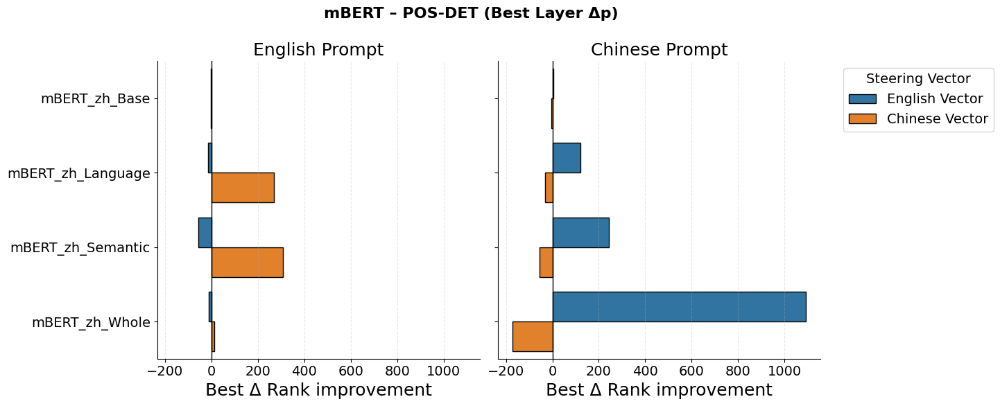

In [44]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# CONJUCTIONS

In [45]:
family = "mBERT"
target = "POS-CONJJ"


full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT-en

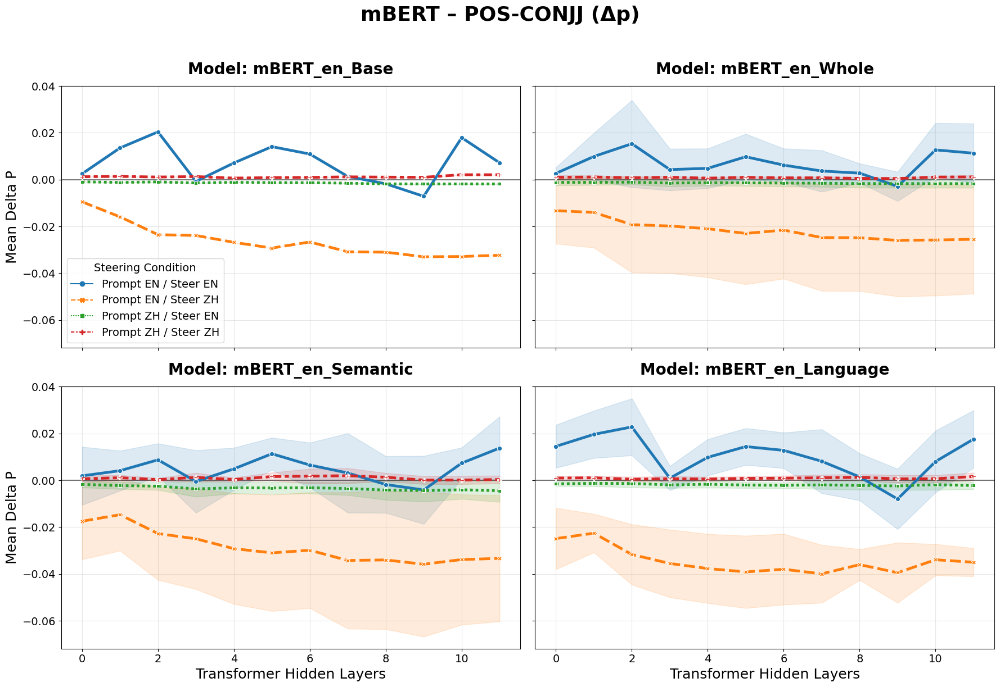

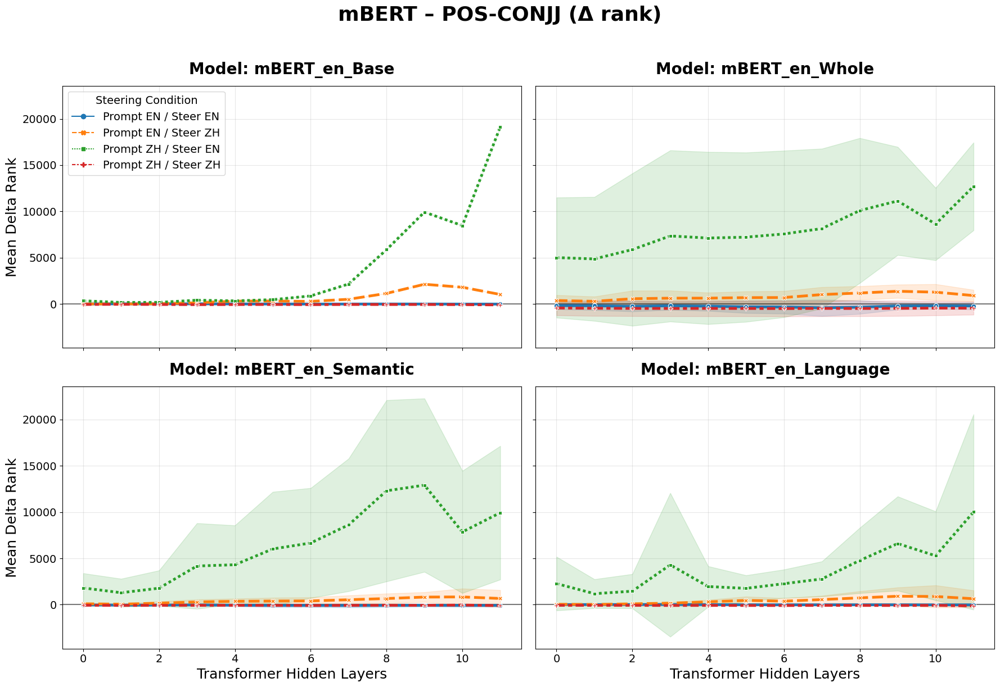

In [46]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-CONJJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      2      0.020396
    mBERT_en_Base          en         zh      0     -0.009487
    mBERT_en_Base          zh         en      0     -0.000963
    mBERT_en_Base          zh         zh     10      0.002087
mBERT_en_Language          en         en      2      0.022809
mBERT_en_Language          en         zh      1     -0.022599
mBERT_en_Language          zh         en      1     -0.001300
mBERT_en_Language          zh         zh     11      0.001621
mBERT_en_Semantic          en         en     11      0.013772
mBERT_en_Semantic          en         zh      1     -0.014700
mBERT_en_Semantic          zh         en      0     -0.001729
mBERT_en_Semantic          zh         zh      7      0.001966
   mBERT_en_Whole          en         en      2      0.015334
   mBERT_en_Whole          en         zh      0     -0.013265
  

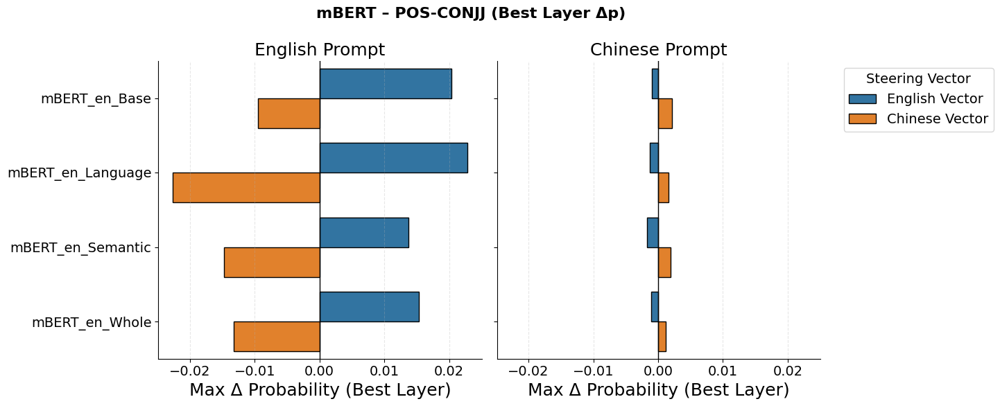

In [47]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-CONJJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en     10       -15.760000
    mBERT_en_Base          en         zh      1        -4.160000
    mBERT_en_Base          zh         en      1       160.680000
    mBERT_en_Base          zh         zh     11      -104.140000
mBERT_en_Language          en         en     10       -21.690000
mBERT_en_Language          en         zh      1        16.250000
mBERT_en_Language          zh         en      1      1183.373333
mBERT_en_Language          zh         zh     11      -132.936667
mBERT_en_Semantic          en         en      7       -95.780000
mBERT_en_Semantic          en         zh      1        48.886667
mBERT_en_Semantic          zh         en      1      1286.173333
mBERT_en_Semantic          zh         zh     11      -104.113333
   mBERT_en_Whole          en         en      7      -415.156667
   mBERT_en_Whole     

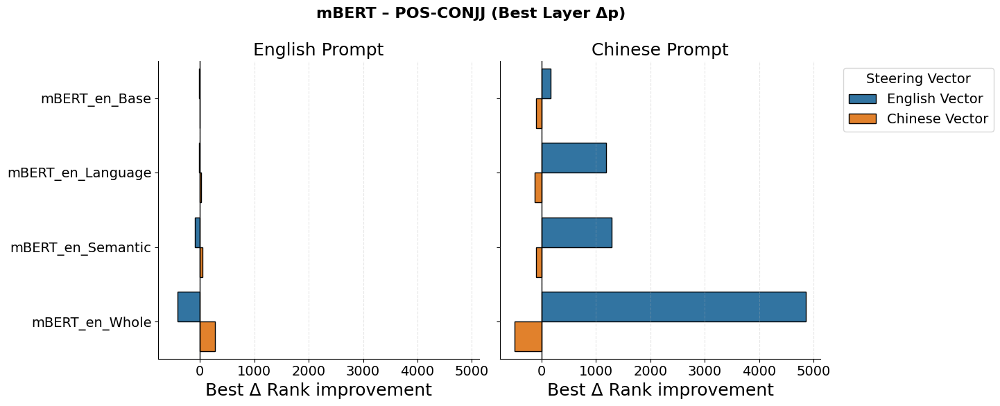

In [48]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

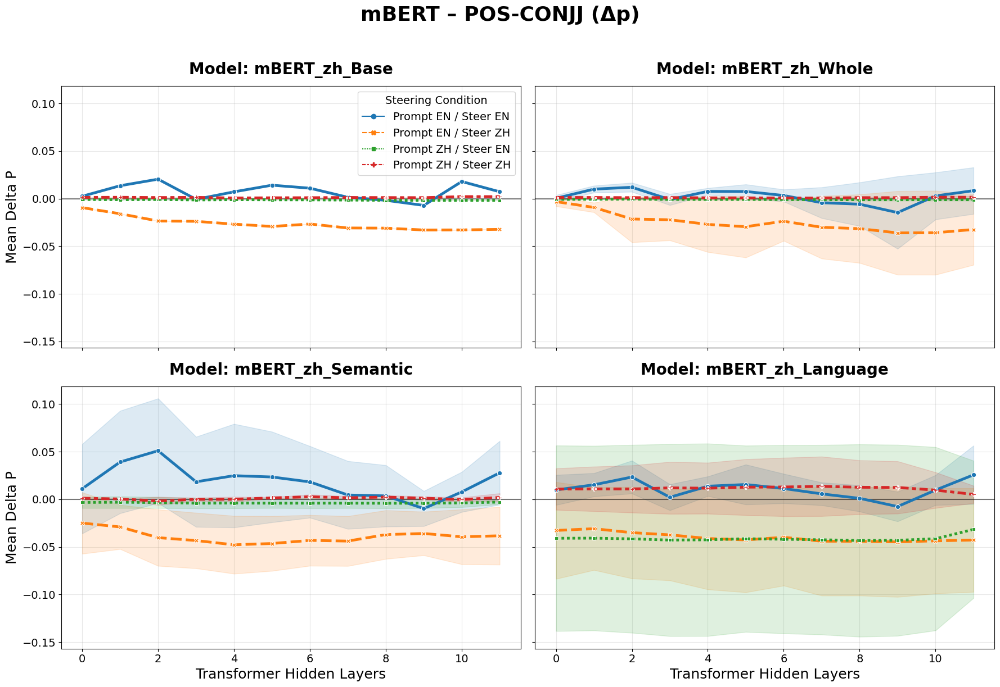

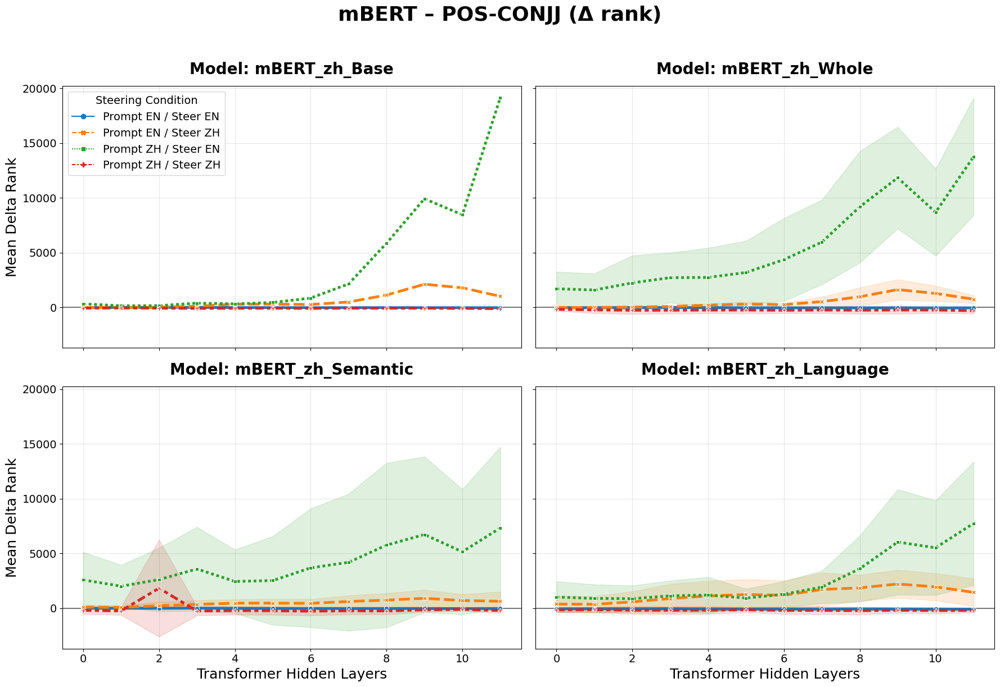

In [49]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – POS-CONJJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      2      0.020396
    mBERT_zh_Base          en         zh      0     -0.009487
    mBERT_zh_Base          zh         en      0     -0.000963
    mBERT_zh_Base          zh         zh     10      0.002087
mBERT_zh_Language          en         en     11      0.025644
mBERT_zh_Language          en         zh      1     -0.030860
mBERT_zh_Language          zh         en     11     -0.031580
mBERT_zh_Language          zh         zh      7      0.013591
mBERT_zh_Semantic          en         en      2      0.050987
mBERT_zh_Semantic          en         zh      0     -0.024980
mBERT_zh_Semantic          zh         en     11     -0.002936
mBERT_zh_Semantic          zh         zh      6      0.002630
   mBERT_zh_Whole          en         en      2      0.011919
   mBERT_zh_Whole          en         zh      0     -0.003174
  

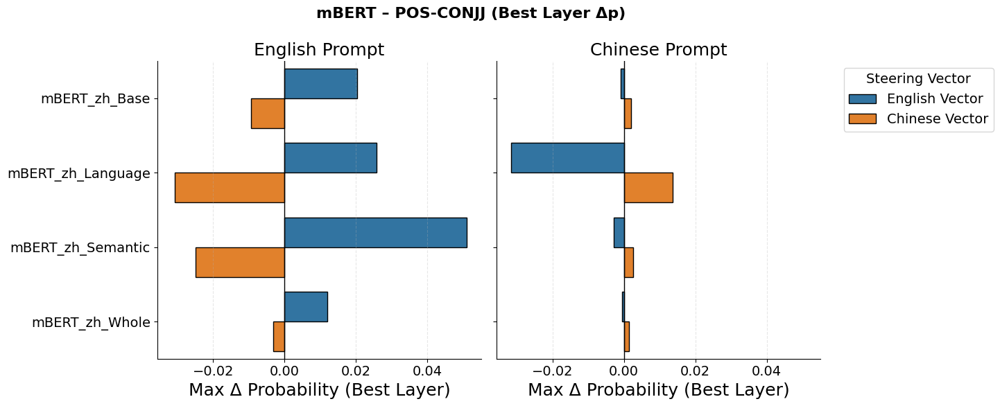

In [50]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – POS-CONJJ (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en     10       -15.760000
    mBERT_zh_Base          en         zh      1        -4.160000
    mBERT_zh_Base          zh         en      1       160.680000
    mBERT_zh_Base          zh         zh     11      -104.140000
mBERT_zh_Language          en         en     11       -88.483333
mBERT_zh_Language          en         zh      1       360.740000
mBERT_zh_Language          zh         en      2       872.173333
mBERT_zh_Language          zh         zh      8      -222.873333
mBERT_zh_Semantic          en         en     10       -33.026667
mBERT_zh_Semantic          en         zh      1        81.713333
mBERT_zh_Semantic          zh         en      1      2009.850000
mBERT_zh_Semantic          zh         zh      6      -268.406667
   mBERT_zh_Whole          en         en     10       -29.566667
   mBERT_zh_Whole     

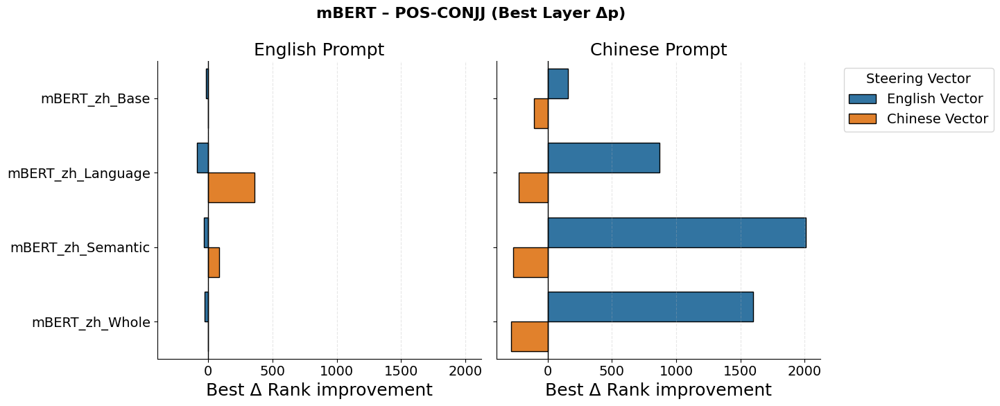

In [51]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# Overal

In [52]:
family = "mBERT"
target = "POS_Overall"


## mBERT-zh

Loading results from: steering_vectors/subject_COL/mBERT/steering_cloze_mBERT_COL_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_GFW/mBERT/steering_cloze_mBERT_GFW_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_JUS/mBERT/steering_cloze_mBERT_JUS_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_KOP/mBERT/steering_cloze_mBERT_KOP_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_TYE/mBERT/steering_cloze_mBERT_TYE_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_ZEK/mBERT/steering_cloze_mBERT_ZEK_POS_Overall_full.pkl


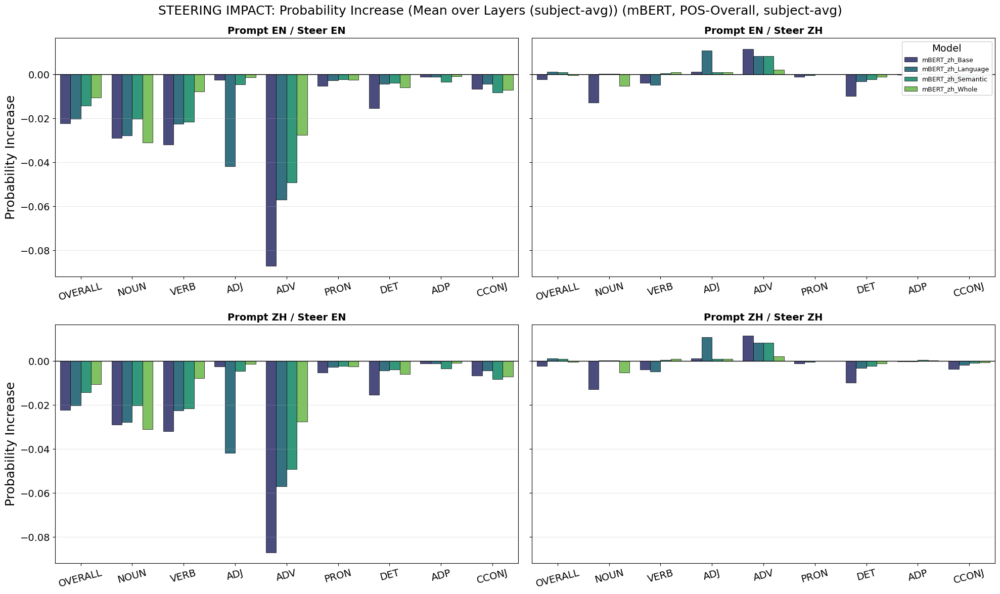

In [53]:
viz.plot_pos_grid_subject_avg(
    subjects=subjects,
    family_name="mBERT",
    target=target,
    metric="delta_p",
    aggregation="overall",      
    model_filter="zh",      
    title_suffix="(mBERT, POS-Overall, subject-avg)",
)

Loading results from: steering_vectors/subject_COL/mBERT/steering_cloze_mBERT_COL_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_GFW/mBERT/steering_cloze_mBERT_GFW_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_JUS/mBERT/steering_cloze_mBERT_JUS_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_KOP/mBERT/steering_cloze_mBERT_KOP_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_TYE/mBERT/steering_cloze_mBERT_TYE_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_ZEK/mBERT/steering_cloze_mBERT_ZEK_POS_Overall_full.pkl


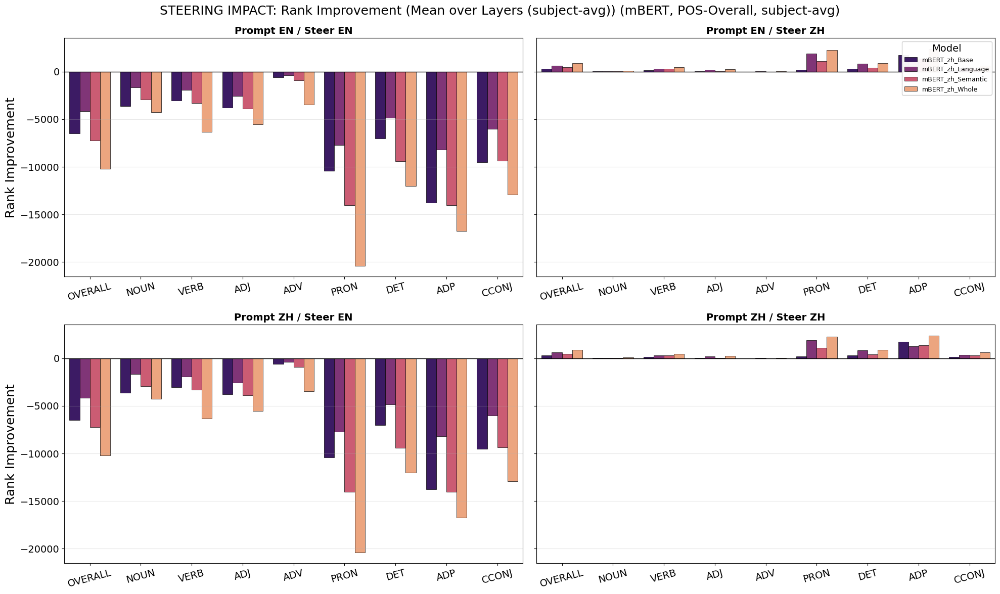

In [54]:
viz.plot_pos_grid_subject_avg(
    subjects=subjects,
    family_name="mBERT",
    target=target,
    metric="delta_rank",
    aggregation="overall",      
    model_filter="zh",      
    title_suffix="(mBERT, POS-Overall, subject-avg)",
)

Loading results from: steering_vectors/subject_COL/mBERT/steering_cloze_mBERT_COL_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_GFW/mBERT/steering_cloze_mBERT_GFW_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_JUS/mBERT/steering_cloze_mBERT_JUS_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_KOP/mBERT/steering_cloze_mBERT_KOP_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_TYE/mBERT/steering_cloze_mBERT_TYE_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_ZEK/mBERT/steering_cloze_mBERT_ZEK_POS_Overall_full.pkl


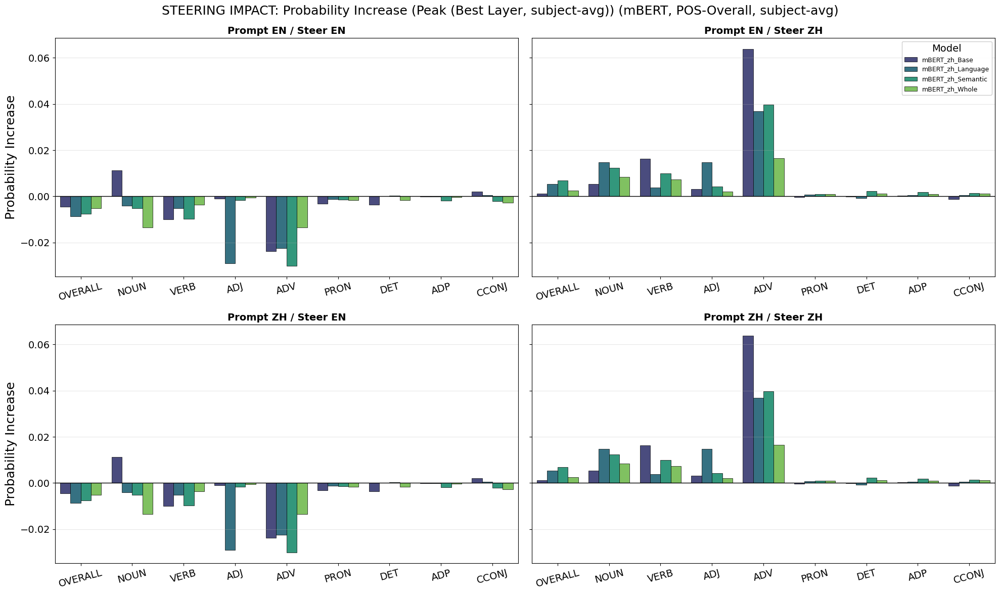

In [55]:
viz.plot_pos_grid_subject_avg(
    subjects=subjects,
    family_name="mBERT",
    target=target,
    metric="delta_p",
    aggregation="best",     
    model_filter="zh",     
    title_suffix="(mBERT, POS-Overall, subject-avg)",
)

Loading results from: steering_vectors/subject_COL/mBERT/steering_cloze_mBERT_COL_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_GFW/mBERT/steering_cloze_mBERT_GFW_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_JUS/mBERT/steering_cloze_mBERT_JUS_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_KOP/mBERT/steering_cloze_mBERT_KOP_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_TYE/mBERT/steering_cloze_mBERT_TYE_POS_Overall_full.pkl
Loading results from: steering_vectors/subject_ZEK/mBERT/steering_cloze_mBERT_ZEK_POS_Overall_full.pkl


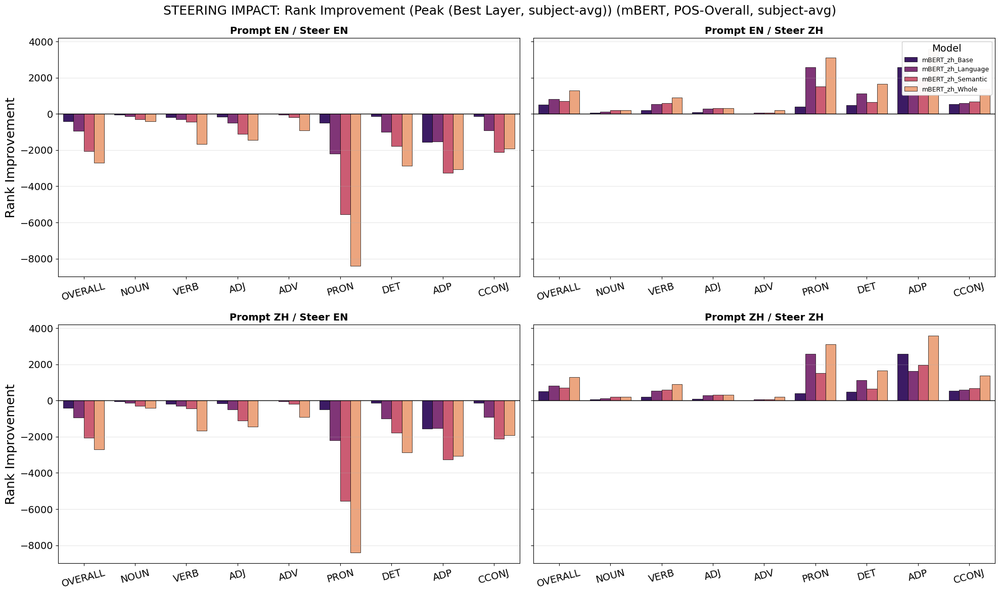

In [56]:
viz.plot_pos_grid_subject_avg(
    subjects=subjects,
    family_name="mBERT",
    target=target,
    metric="delta_rank",
    aggregation="best",     
    model_filter="zh",       
    title_suffix="(mBERT, POS-Overall, subject-avg)",
)